# Project - Time Series Forecasting

# Problem:

# For this particular assignment, the data of different types of wine sales in the 20th century is to be analysed. Both of these data are from the same company but of different wines. As an analyst in the ABC Estate Wines, you are tasked to analyse and forecast Wine Sales in the 20th century.

# Data set for the Problem: Sparkling.csv and Rose.csv

### Importing necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pylab import rcParams
from statsmodels.graphics.tsaplots import month_plot
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.tsa.seasonal import seasonal_decompose
from IPython.display import display
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Part 1: Data set Sparkling.csv

## 1. Read the data as an appropriate Time Series data and plot the data.

## Ans:

### Read the data from the '.csv' file as a monthly Time Series

In [2]:
df1 = pd.read_csv('Sparkling.csv')

In [3]:
df1.head()

,YearMonth,Sparkling
0,1980-01,1686
1,1980-02,1591
2,1980-03,2304
3,1980-04,1712
4,1980-05,1471


In [4]:
df1.tail()

,YearMonth,Sparkling
182,1995-03,1897
183,1995-04,1862
184,1995-05,1670
185,1995-06,1688
186,1995-07,2031


In [5]:
df1.shape

(187, 2)

### Creating the Time Stamps and adding to the data frame to make it a Time Series Data

In [6]:
date1 = pd.date_range(start='1/01/1980', end= '7/31/1995', freq='M')
date1

DatetimeIndex(['1980-01-31', '1980-02-29', '1980-03-31', '1980-04-30',
               '1980-05-31', '1980-06-30', '1980-07-31', '1980-08-31',
               '1980-09-30', '1980-10-31',
               ...
               '1994-10-31', '1994-11-30', '1994-12-31', '1995-01-31',
               '1995-02-28', '1995-03-31', '1995-04-30', '1995-05-31',
               '1995-06-30', '1995-07-31'],
              dtype='datetime64[ns]', length=187, freq='M')

In [7]:
df1['Time_Stamp'] = pd.DataFrame(date1)
df1.head()

,YearMonth,Sparkling,Time_Stamp
0,1980-01,1686,1980-01-31
1,1980-02,1591,1980-02-29
2,1980-03,2304,1980-03-31
3,1980-04,1712,1980-04-30
4,1980-05,1471,1980-05-31


In [8]:
df1.set_index('Time_Stamp',inplace=True)
df1.head()

,YearMonth,Sparkling
Time_Stamp,,
1980-01-31,1980-01,1686
1980-02-29,1980-02,1591
1980-03-31,1980-03,2304
1980-04-30,1980-04,1712
1980-05-31,1980-05,1471


In [9]:
df1.drop("YearMonth", axis = 1, inplace = True)
df1.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


### Plot the Time Series to understand the behaviour of the data

In [10]:
rcParams['figure.figsize'] = 20,8

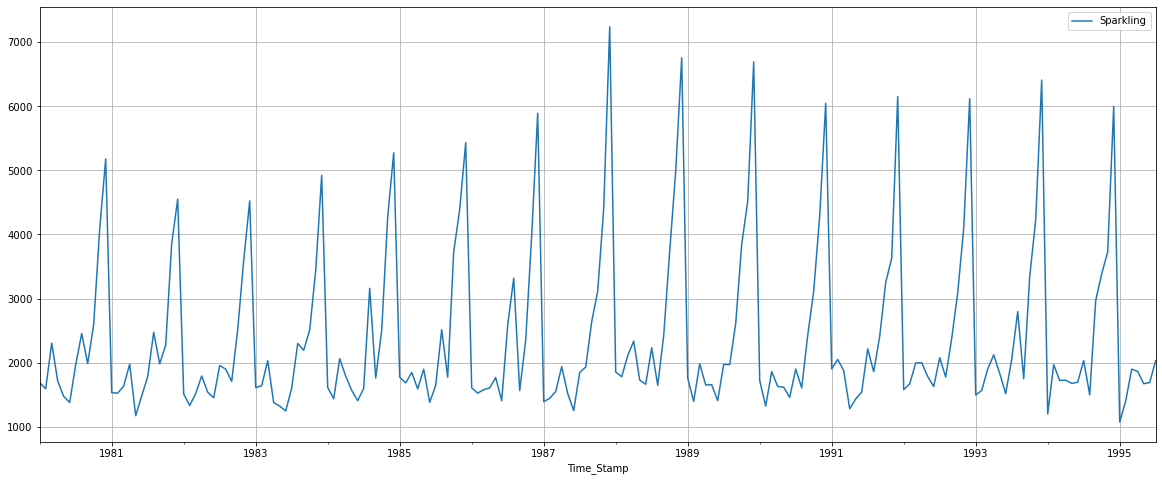

In [11]:
df1.plot()
plt.grid();

## 2. Perform appropriate Exploratory Data Analysis to understand the data and also perform decomposition.

## Ans:

### Check the basic measures of descriptive statistics

In [12]:
df1.describe()

,Sparkling
count,187.000000
mean,2402.417112
std,1295.111540
min,1070.000000
25%,1605.000000
50%,1874.000000
75%,2549.000000
max,7242.000000


### Plot a boxplot to understand the spread of sales across different years and within different months across years.

### Yearly Plot

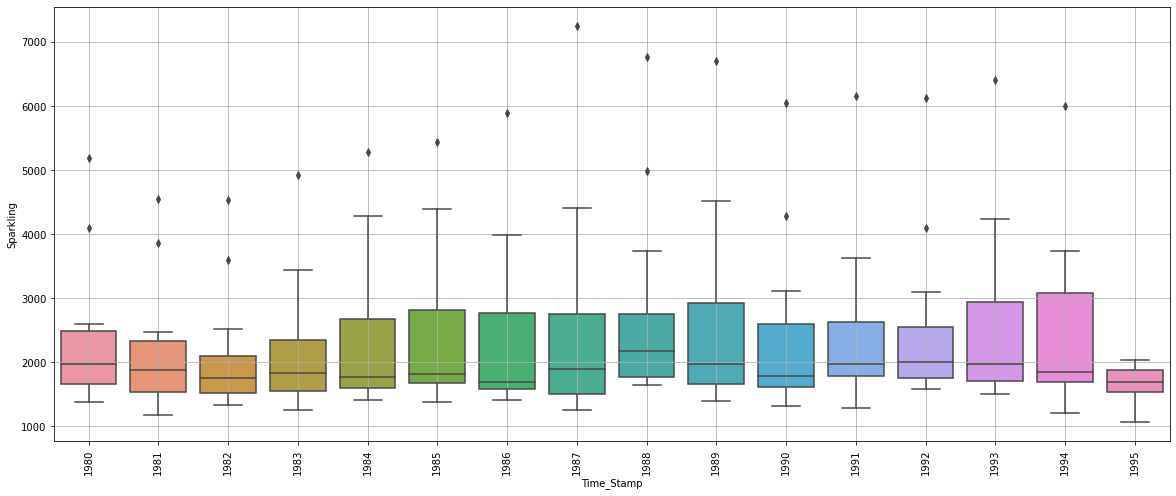

In [13]:
sns.boxplot(x = df1.index.year,y = df1['Sparkling'])
plt.xticks(rotation=90)
plt.grid();

### Monthly Plot

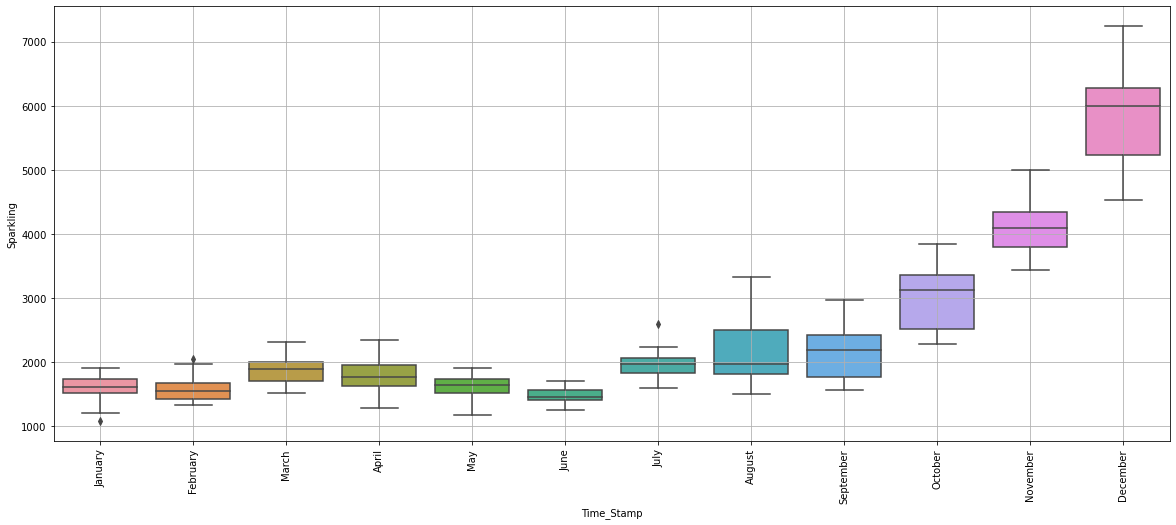

In [14]:
sns.boxplot(x = df1.index.month_name(),y = df1['Sparkling'])
plt.xticks(rotation=90)
plt.grid();

### Plot a time series monthplot to understand the spread of sales across different years and within different months across years

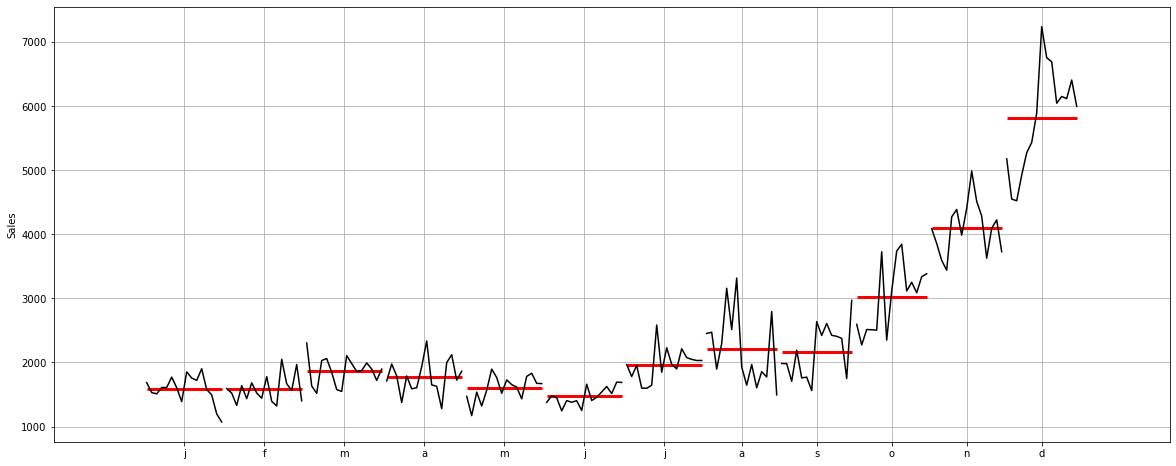

In [15]:
month_plot(df1['Sparkling'],ylabel='Sales')
plt.grid();

### Plot a graph of monthly sales across years

In [16]:
monthly_sales_across_years1 = pd.pivot_table(df1, values = 'Sparkling', columns = df1.index.month_name(), index = df1.index.year)
monthly_sales_across_years1

Time_Stamp,April,August,December,February,January,July,June,March,May,November,October,September
Time_Stamp,,,,,,,,,,,,
1980,1712.0,2453.0,5179.0,1591.0,1686.0,1966.0,1377.0,2304.0,1471.0,4087.0,2596.0,1984.0
1981,1976.0,2472.0,4551.0,1523.0,1530.0,1781.0,1480.0,1633.0,1170.0,3857.0,2273.0,1981.0
1982,1790.0,1897.0,4524.0,1329.0,1510.0,1954.0,1449.0,1518.0,1537.0,3593.0,2514.0,1706.0
1983,1375.0,2298.0,4923.0,1638.0,1609.0,1600.0,1245.0,2030.0,1320.0,3440.0,2511.0,2191.0
1984,1789.0,3159.0,5274.0,1435.0,1609.0,1597.0,1404.0,2061.0,1567.0,4273.0,2504.0,1759.0
1985,1589.0,2512.0,5434.0,1682.0,1771.0,1645.0,1379.0,1846.0,1896.0,4388.0,3727.0,1771.0
1986,1605.0,3318.0,5891.0,1523.0,1606.0,2584.0,1403.0,1577.0,1765.0,3987.0,2349.0,1562.0
1987,1935.0,1930.0,7242.0,1442.0,1389.0,1847.0,1250.0,1548.0,1518.0,4405.0,3114.0,2638.0
1988,2336.0,1645.0,6757.0,1779.0,1853.0,2230.0,1661.0,2108.0,1728.0,4988.0,3740.0,2421.0


In [17]:
monthly_sales_across_years1 = pd.pivot_table(df1, values = 'Sparkling', columns = df1.index.month, index = df1.index.year)
monthly_sales_across_years1

Time_Stamp,1,2,3,4,5,6,7,8,9,10,11,12
Time_Stamp,,,,,,,,,,,,
1980,1686.0,1591.0,2304.0,1712.0,1471.0,1377.0,1966.0,2453.0,1984.0,2596.0,4087.0,5179.0
1981,1530.0,1523.0,1633.0,1976.0,1170.0,1480.0,1781.0,2472.0,1981.0,2273.0,3857.0,4551.0
1982,1510.0,1329.0,1518.0,1790.0,1537.0,1449.0,1954.0,1897.0,1706.0,2514.0,3593.0,4524.0
1983,1609.0,1638.0,2030.0,1375.0,1320.0,1245.0,1600.0,2298.0,2191.0,2511.0,3440.0,4923.0
1984,1609.0,1435.0,2061.0,1789.0,1567.0,1404.0,1597.0,3159.0,1759.0,2504.0,4273.0,5274.0
1985,1771.0,1682.0,1846.0,1589.0,1896.0,1379.0,1645.0,2512.0,1771.0,3727.0,4388.0,5434.0
1986,1606.0,1523.0,1577.0,1605.0,1765.0,1403.0,2584.0,3318.0,1562.0,2349.0,3987.0,5891.0
1987,1389.0,1442.0,1548.0,1935.0,1518.0,1250.0,1847.0,1930.0,2638.0,3114.0,4405.0,7242.0
1988,1853.0,1779.0,2108.0,2336.0,1728.0,1661.0,2230.0,1645.0,2421.0,3740.0,4988.0,6757.0


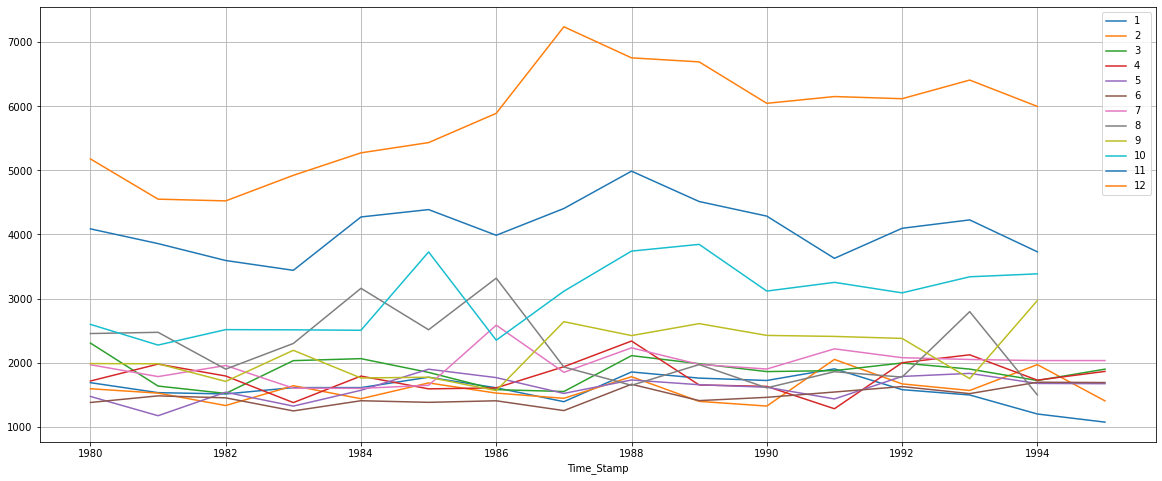

In [18]:
monthly_sales_across_years1.plot()
plt.grid()
plt.legend(loc='best');

### Plot the Empirical Cumulative Distribution.

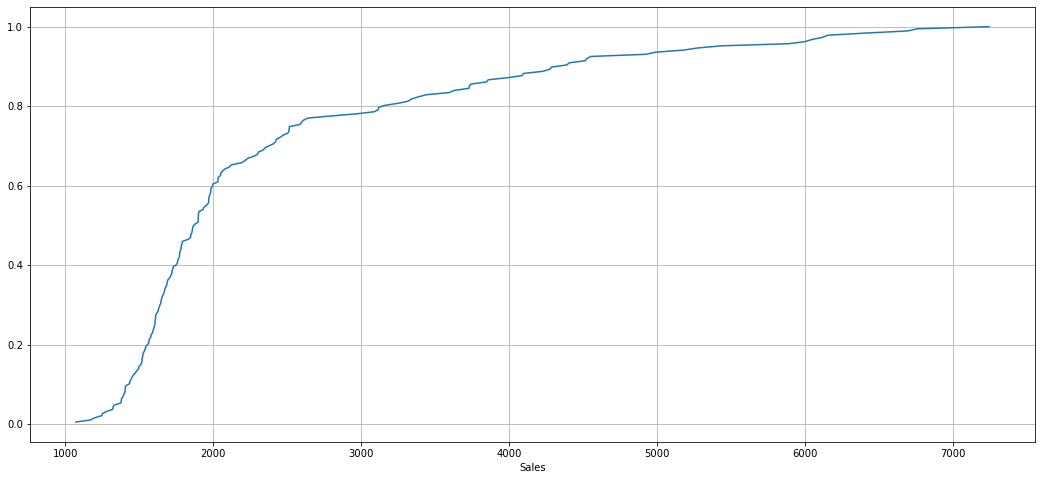

In [19]:
plt.figure(figsize = (18, 8))
cdf = ECDF(df1['Sparkling'])
plt.plot(cdf.x, cdf.y, label = "statmodels");
plt.grid()
plt.xlabel('Sales');

### Plot the average Sparkling Wine Sales per month and the month on month percentage change of Sales.

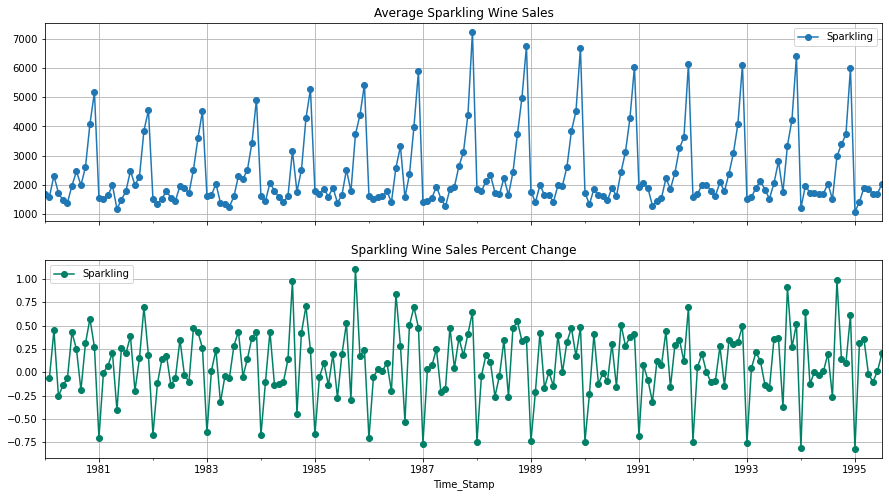

In [20]:
average    = df1.groupby(df1.index)["Sparkling"].mean()
pct_change = df1.groupby(df1.index)["Sparkling"].sum().pct_change()

fig, (axis1,axis2) = plt.subplots(2,1,sharex=True,figsize=(15,8))

# plot average Sparkling Wine Sales over time(year-month)
ax1 = average.plot(legend=True,ax=axis1,marker='o',title="Average Sparkling Wine Sales",grid=True)
ax1.set_xticks(range(len(average)))
ax1.set_xticklabels(average.index.tolist())
# plot precent change for Sparkling Wine Sales over time(year-month)
ax2 = pct_change.plot(legend=True,ax=axis2,marker='o',colormap="summer",title="Sparkling Wine Sales Percent Change",grid=True)

### Decompose the Time Series and plot the different components.

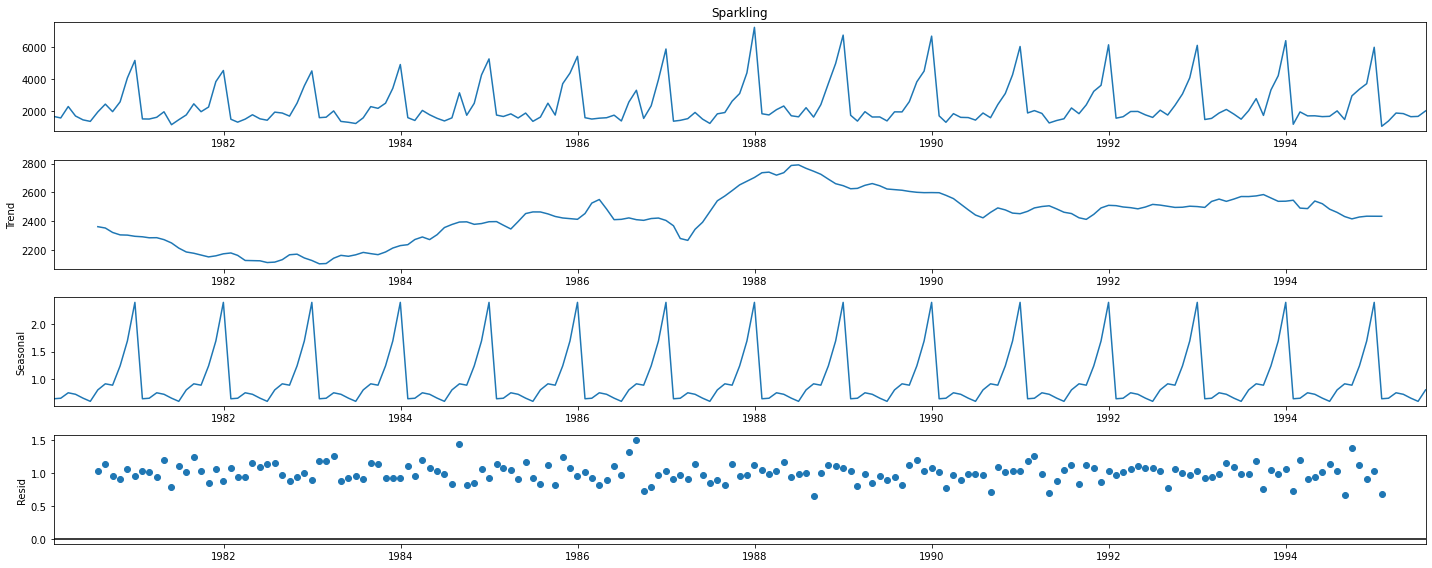

In [21]:
decomposition = seasonal_decompose(df1['Sparkling'],model='multiplicative')
decomposition.plot();

## 3. Split the data into training and test. The test data should start in 1991.

## Ans:

In [22]:
train=df1[df1.index.year < 1991]
test=df1[df1.index.year >= 1991]

In [23]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

First few rows of Training Data


,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


Last few rows of Training Data


,Sparkling
Time_Stamp,
1990-08-31,1605
1990-09-30,2424
1990-10-31,3116
1990-11-30,4286
1990-12-31,6047


First few rows of Test Data


,Sparkling
Time_Stamp,
1991-01-31,1902
1991-02-28,2049
1991-03-31,1874
1991-04-30,1279
1991-05-31,1432


Last few rows of Test Data


,Sparkling
Time_Stamp,
1995-03-31,1897
1995-04-30,1862
1995-05-31,1670
1995-06-30,1688
1995-07-31,2031


In [24]:
print(train.shape)
print(test.shape)

(132, 1)
(55, 1)


## 4. Build various exponential smoothing models on the training data and evaluate the model using RMSE on the test data.
## Other models such as regression,naïve forecast models, simple average models etc. should also be built on the training data and check the performance on the test data using RMSE.


## Ans:

### Defining Mean Absolute Percentage

In [25]:
## Mean Absolute Percentage - Function Definition

def MAPE(y, yhat): 
    y, yhat = np.array(y), np.array(yhat)
    try:
        mape =  round(np.sum(np.abs(yhat - y)) / np.sum(y) * 100,2)
    except:
        print("Observed values are empty")
        mape = np.nan
    return mape

### Method 1: Simple Exponential Smoothing

In [26]:
SES_train = train.copy()
SES_test = test.copy()

In [27]:
model_SES = SimpleExpSmoothing(SES_train['Sparkling'])

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


### Model Evaluation

In [28]:
results = pd.DataFrame({'Alpha Values':[],'Train RMSE':[],'Train MAPE':[]
                                ,'Test RMSE': [],'Test MAPE': []})
results

,Alpha Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE


In [29]:
for i in np.arange(0.3,1,0.1):
    model_SES_alpha_i = model_SES.fit(smoothing_level=i,optimized=True,use_brute=True)
    SES_train['predict',i] = model_SES_alpha_i.fittedvalues
    SES_test['predict',i] = model_SES_alpha_i.forecast(steps=55)
    
    rmse_model1_train_i = metrics.mean_squared_error(SES_train['Sparkling'],SES_train['predict',i],squared=False)
    mape_model1_train_i = MAPE(SES_train['Sparkling'],SES_train['predict',i])
    
    rmse_model1_test_i = metrics.mean_squared_error(SES_test['Sparkling'],SES_test['predict',i],squared=False)
    mape_model1_test_i = MAPE(SES_test['Sparkling'],SES_test['predict',i])
    
    results = results.append({'Alpha Values':i,'Train RMSE':rmse_model1_train_i 
                                      ,'Train MAPE': mape_model1_train_i,'Test RMSE':rmse_model1_test_i
                                      ,'Test MAPE':mape_model1_test_i}, ignore_index=True)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

In [30]:
results

,Alpha Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,1359.422161,43.80,1935.507132,75.66
1,0.4,1352.562367,42.79,2311.919615,91.55
2,0.5,1343.994119,41.18,2666.351413,106.27
3,0.6,1338.801428,39.81,2979.204388,118.77
4,0.7,1338.843297,38.56,3249.944092,129.34
5,0.8,1344.462034,37.60,3483.801006,138.34
6,0.9,1355.723493,36.79,3686.794285,146.08


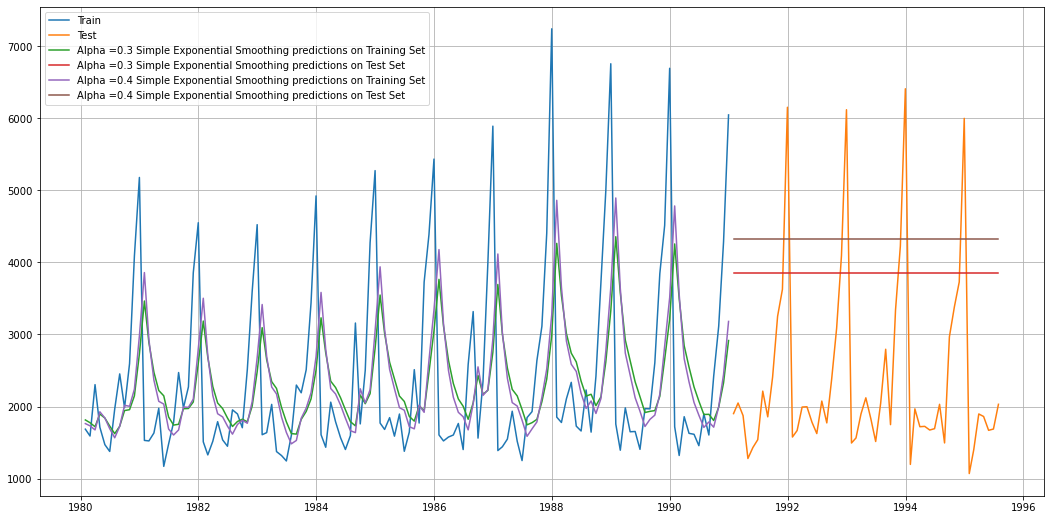

In [31]:
plt.figure(figsize=(18,9))
plt.plot(SES_train['Sparkling'], label='Train')
plt.plot(SES_test['Sparkling'], label='Test')

plt.plot(SES_train['predict', 0.3], label='Alpha =0.3 Simple Exponential Smoothing predictions on Training Set')
plt.plot(SES_test['predict', 0.3], label='Alpha =0.3 Simple Exponential Smoothing predictions on Test Set')

plt.plot(SES_train['predict', 0.4], label='Alpha =0.4 Simple Exponential Smoothing predictions on Training Set')
plt.plot(SES_test['predict', 0.4], label='Alpha =0.4 Simple Exponential Smoothing predictions on Test Set')


plt.legend(loc='best')
plt.grid();

In [32]:
resultsDf = pd.DataFrame({'Test RMSE': [results['Test RMSE'][0],results['Test RMSE'][1]]
                            ,'Test MAPE': [results['Test MAPE'][0],results['Test MAPE'][1]]}
                           ,index=['Alpha=0.3,SimpleExponentialSmoothing','Alpha=0.4,SimpleExponentialSmoothing'])

resultsDf

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55


### Method 2: Double Exponential Smoothing

In [33]:
DES_train = train.copy()
DES_test = test.copy()

In [34]:
model_DES = Holt(DES_train['Sparkling'])

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


### Model Evaluation

In [35]:
resultsDf_1 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Train RMSE':[],'Train MAPE':[]
                                ,'Test RMSE': [],'Test MAPE': []})
resultsDf_1

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE


In [36]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        model_DES_alpha_i_j = model_DES.fit(smoothing_level=i,smoothing_slope=j,optimized=True,use_brute=True)
        DES_train['predict',i,j] = model_DES_alpha_i_j.fittedvalues
        DES_test['predict',i,j] = model_DES_alpha_i_j.forecast(steps=55)
        
        rmse_model2_train = metrics.mean_squared_error(DES_train['Sparkling'],DES_train['predict',i,j],squared=False)
        mape_model2_train = MAPE(DES_train['Sparkling'],DES_train['predict',i,j])
        
        rmse_model2_test = metrics.mean_squared_error(DES_test['Sparkling'],DES_test['predict',i,j],squared=False)
        mape_model2_test = MAPE(DES_test['Sparkling'],DES_test['predict',i,j])
        
        resultsDf_1 = resultsDf_1.append({'Alpha Values':i,'Beta Values':j,'Train RMSE':rmse_model2_train
                                      ,'Train MAPE': mape_model2_train,'Test RMSE':rmse_model2_test
                                      ,'Test MAPE':mape_model2_test}, ignore_index=True)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

In [37]:
resultsDf_1

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,1590.151687,53.80,18259.110704,675.28
1,0.3,0.4,1681.706138,57.15,26069.841401,960.18
2,0.3,0.5,1771.290968,59.94,34401.512440,1264.55
3,0.3,0.6,1848.583857,62.10,42162.748095,1548.94
4,0.3,0.7,1900.315419,62.91,47832.397419,1757.91
...,...,...,...,...,...,...
59,1.0,0.6,1753.362277,45.75,49327.087977,1824.42
60,1.0,0.7,1825.157068,47.96,52655.765663,1945.23
61,1.0,0.8,1901.992950,50.09,55442.273880,2046.36
62,1.0,0.9,1985.351410,52.00,57823.177011,2132.75


In [38]:
resultsDf_1.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,1590.151687,53.80,18259.110704,675.28
8,0.4,0.3,1568.527730,50.15,23878.496940,886.00
1,0.3,0.4,1681.706138,57.15,26069.841401,960.18
16,0.5,0.3,1530.223975,45.98,27095.532414,1007.39
24,0.6,0.3,1506.223120,42.82,29070.722592,1082.18


In [39]:
resultsDf_1.sort_values(by=['Test MAPE']).head()

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,1590.151687,53.80,18259.110704,675.28
8,0.4,0.3,1568.527730,50.15,23878.496940,886.00
1,0.3,0.4,1681.706138,57.15,26069.841401,960.18
16,0.5,0.3,1530.223975,45.98,27095.532414,1007.39
24,0.6,0.3,1506.223120,42.82,29070.722592,1082.18


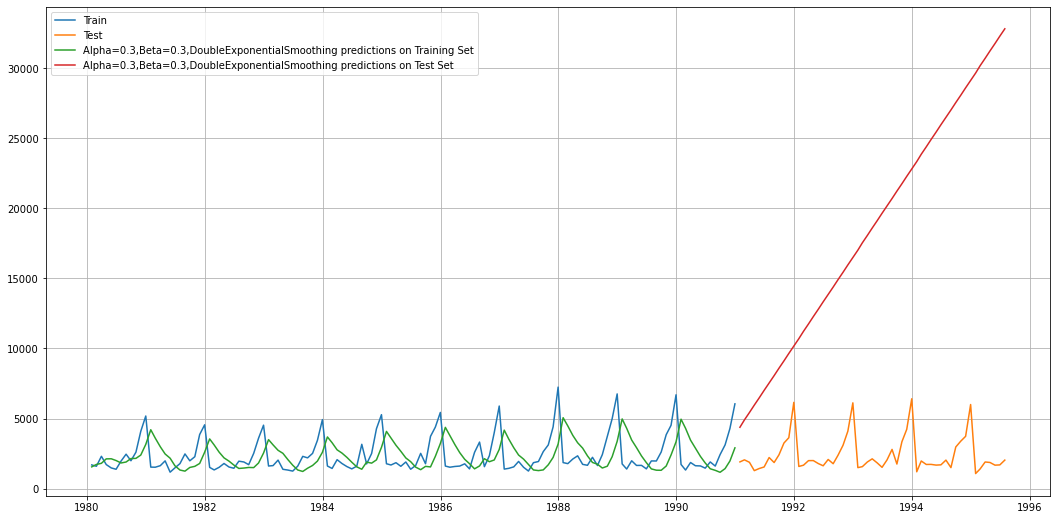

In [40]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(DES_train['Sparkling'], label='Train')
plt.plot(DES_test['Sparkling'], label='Test')

plt.plot(DES_train['predict', 0.3, 0.3], label='Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing predictions on Training Set')
plt.plot(DES_test['predict', 0.3, 0.3], label='Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid();

In [41]:
resultsDf2 = pd.DataFrame({'Test RMSE': [resultsDf_1['Test RMSE'][0]],'Test MAPE':[resultsDf_1['Test MAPE'][0]]}
                           ,index=['Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing'])

In [42]:
resultsDf2

,Test RMSE,Test MAPE
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28


In [43]:
resultsDf_2 = pd.concat([resultsDf, resultsDf2])
resultsDf_2

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28


### Method 3: Triple Exponential Smoothing

In [44]:
TES_train = train.copy()
TES_test = test.copy()

In [45]:
model_TES = ExponentialSmoothing(TES_train['Sparkling'])

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


### Model Evaluation

In [46]:
## First we will define an empty dataframe to store our values from the loop

resultsDf3 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Gamma Values':[],'Train RMSE':[],'Train MAPE':[]
                                ,'Test RMSE': [],'Test MAPE': []})
resultsDf3

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE


In [47]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        for k in np.arange(0.3,1.1,0.1):
            model_TES_alpha_i_j_k = model_TES.fit(smoothing_level=i,smoothing_slope=j,smoothing_seasonal=k,optimized=True,use_brute=True)
            TES_train['predict',i,j,k] = model_TES_alpha_i_j_k.fittedvalues
            TES_test['predict',i,j,k] = model_TES_alpha_i_j_k.forecast(steps=55)
        
            rmse_model3_train = metrics.mean_squared_error(TES_train['Sparkling'],TES_train['predict',i,j,k],squared=False)
            mape_model3_train = MAPE(TES_train['Sparkling'],TES_train['predict',i,j,k])
        
            rmse_model3_test = metrics.mean_squared_error(TES_test['Sparkling'],TES_test['predict',i,j,k],squared=False)
            mape_model3_test = MAPE(TES_test['Sparkling'],TES_test['predict',i,j,k])
        
            resultsDf3 = resultsDf3.append({'Alpha Values':i,'Beta Values':j,'Gamma Values':k,'Train RMSE':rmse_model3_train
                                      ,'Train MAPE': mape_model3_train,'Test RMSE':rmse_model3_test
                                      ,'Test MAPE':mape_model3_test}, ignore_index=True)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

In [48]:
resultsDf3

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,0.3,1359.422161,43.80,1935.507132,75.66
1,0.3,0.3,0.4,1359.422161,43.80,1935.507132,75.66
2,0.3,0.3,0.5,1359.422161,43.80,1935.507132,75.66
3,0.3,0.3,0.6,1359.422161,43.80,1935.507132,75.66
4,0.3,0.3,0.7,1359.422161,43.80,1935.507132,75.66
...,...,...,...,...,...,...,...
507,1.0,1.0,0.6,1373.082528,35.83,3864.279352,152.87
508,1.0,1.0,0.7,1373.082528,35.83,3864.279352,152.87
509,1.0,1.0,0.8,1373.082528,35.83,3864.279352,152.87
510,1.0,1.0,0.9,1373.082528,35.83,3864.279352,152.87


In [49]:
resultsDf3.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,0.3,1359.422161,43.8,1935.507132,75.66
34,0.3,0.7,0.5,1359.422161,43.8,1935.507132,75.66
35,0.3,0.7,0.6,1359.422161,43.8,1935.507132,75.66
36,0.3,0.7,0.7,1359.422161,43.8,1935.507132,75.66
37,0.3,0.7,0.8,1359.422161,43.8,1935.507132,75.66


In [50]:
resultsDf3.sort_values(by=['Test MAPE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,0.3,1359.422161,43.8,1935.507132,75.66
34,0.3,0.7,0.5,1359.422161,43.8,1935.507132,75.66
35,0.3,0.7,0.6,1359.422161,43.8,1935.507132,75.66
36,0.3,0.7,0.7,1359.422161,43.8,1935.507132,75.66
37,0.3,0.7,0.8,1359.422161,43.8,1935.507132,75.66


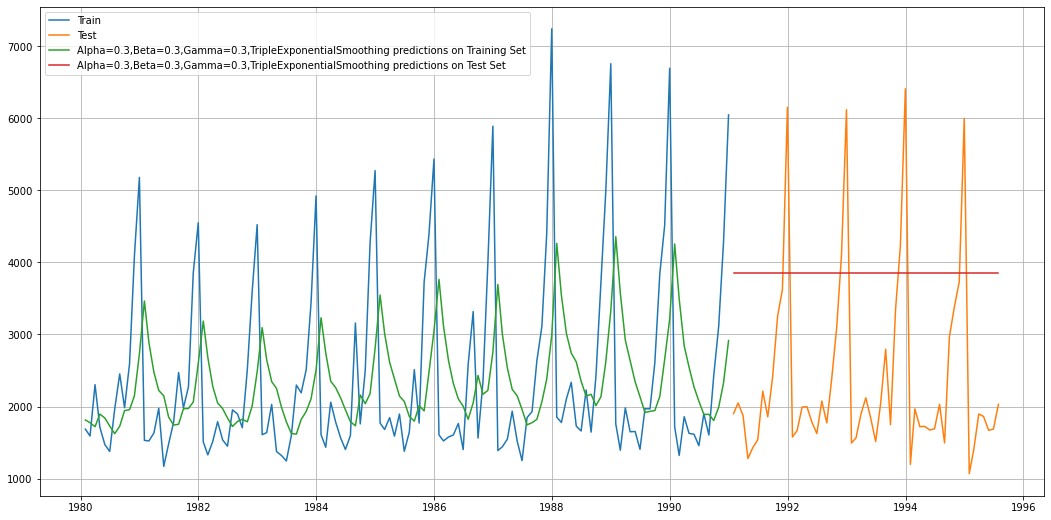

In [51]:
## Plotting on both the Training and Test data using brute force alpha, beta and gamma determination

plt.figure(figsize=(18,9))
plt.plot(TES_train['Sparkling'], label='Train')
plt.plot(TES_test['Sparkling'], label='Test')

plt.plot(TES_train['predict', 0.3, 0.3, 0.3], label='Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing predictions on Training Set')
plt.plot(TES_test['predict', 0.3, 0.3, 0.3], label='Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid();

In [52]:
results3 = pd.DataFrame({'Test RMSE': [resultsDf3['Test RMSE'][0]],'Test MAPE':[resultsDf3['Test MAPE'][0]]}
                           ,index=['Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing'])

resultsDf_3 = pd.concat([resultsDf_2, results3])
resultsDf_3

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66


### Method 4: Linear Regression

In [53]:
train_time = [i+1 for i in range(len(train))]
test_time = [i+133 for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
Test Time instance 
 [133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187]


In [54]:
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [55]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data','\n',LinearRegression_train.head(),'\n')
print('Last few rows of Training Data','\n',LinearRegression_train.tail(),'\n')
print('First few rows of Test Data','\n',LinearRegression_test.head(),'\n')
print('Last few rows of Test Data','\n',LinearRegression_test.tail(),'\n')

First few rows of Training Data 
             Sparkling  time
Time_Stamp                 
1980-01-31       1686     1
1980-02-29       1591     2
1980-03-31       2304     3
1980-04-30       1712     4
1980-05-31       1471     5 

Last few rows of Training Data 
             Sparkling  time
Time_Stamp                 
1990-08-31       1605   128
1990-09-30       2424   129
1990-10-31       3116   130
1990-11-30       4286   131
1990-12-31       6047   132 

First few rows of Test Data 
             Sparkling  time
Time_Stamp                 
1991-01-31       1902   133
1991-02-28       2049   134
1991-03-31       1874   135
1991-04-30       1279   136
1991-05-31       1432   137 

Last few rows of Test Data 
             Sparkling  time
Time_Stamp                 
1995-03-31       1897   183
1995-04-30       1862   184
1995-05-31       1670   185
1995-06-30       1688   186
1995-07-31       2031   187 



In [56]:
lr = LinearRegression()

In [57]:
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Sparkling'].values)

LinearRegression()

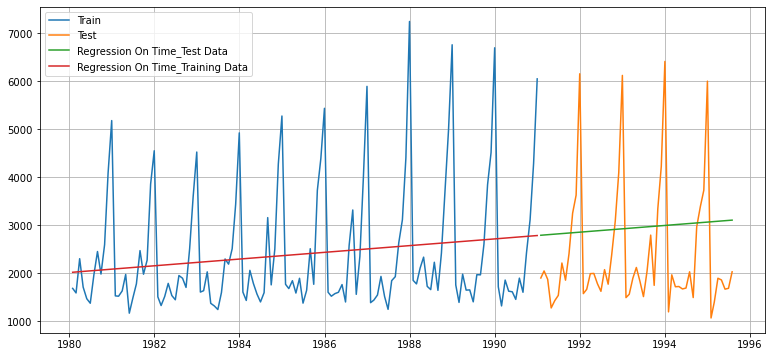

In [58]:
train_predictions_model4 = lr.predict(LinearRegression_train[['time']])
LinearRegression_train['RegOnTime'] = train_predictions_model4

test_predictions_model4 = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model4

plt.figure(figsize=(13,6))
plt.plot(train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')
plt.plot(LinearRegression_train['RegOnTime'], label='Regression On Time_Training Data')
plt.legend(loc='best')
plt.grid();

### Model Evaluation

In [59]:
rmse_model4_train = metrics.mean_squared_error(train['Sparkling'],train_predictions_model4,squared=False)
mape_model4_train = MAPE(train['Sparkling'],train_predictions_model4)
print("For RegressionOnTime forecast on the Training Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model4_train, mape_model4_train))

For RegressionOnTime forecast on the Training Data,  RMSE is 1279.322 MAPE is 40.05


In [60]:
rmse_model4_test = metrics.mean_squared_error(test['Sparkling'],test_predictions_model4,squared=False)
mape_model4_test = MAPE(test['Sparkling'],test_predictions_model4)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model4_test, mape_model4_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 1389.135 MAPE is 50.15


In [61]:
resultsDf4 = pd.DataFrame({'Test RMSE': [rmse_model4_test],'Test MAPE': [mape_model4_test]},index=['RegressionOnTime'])
resultsDf4

,Test RMSE,Test MAPE
RegressionOnTime,1389.135175,50.15


In [62]:
resultsDf_4 = pd.concat([resultsDf_3,resultsDf4])
resultsDf_4

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15


### Method 5: Naive Approach

In [63]:
NaiveModel_train = train.copy()
NaiveModel_test = test.copy()

In [64]:
## Let us get the last value (or the most recent value) of the training set.

NaiveModel_train['naive'] = np.asarray(train['Sparkling'])[len(np.asarray(train['Sparkling']))-1]
NaiveModel_train['naive'].head()

Time_Stamp
1980-01-31    6047
1980-02-29    6047
1980-03-31    6047
1980-04-30    6047
1980-05-31    6047
Name: naive, dtype: int64

In [65]:
NaiveModel_test['naive'] = np.asarray(test['Sparkling'])[len(np.asarray(test['Sparkling']))-1]
NaiveModel_test['naive'].head()

Time_Stamp
1991-01-31    2031
1991-02-28    2031
1991-03-31    2031
1991-04-30    2031
1991-05-31    2031
Name: naive, dtype: int64

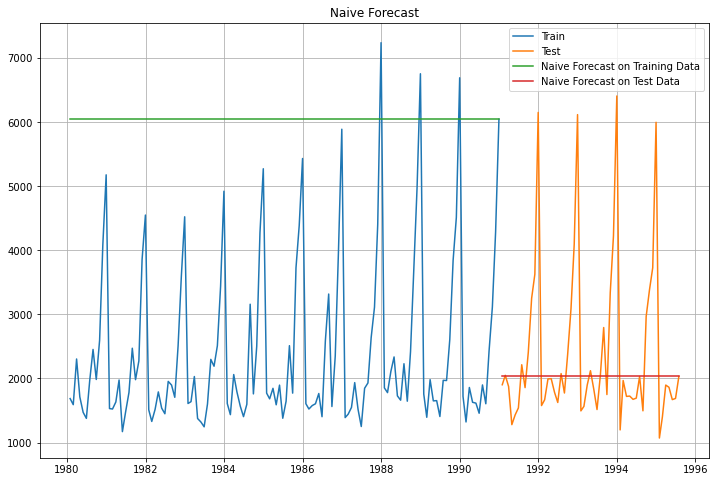

In [66]:
plt.figure(figsize=(12,8))
plt.plot(NaiveModel_train['Sparkling'], label='Train')
plt.plot(test['Sparkling'], label='Test')
plt.plot(NaiveModel_train['naive'], label='Naive Forecast on Training Data')
plt.plot(NaiveModel_test['naive'], label='Naive Forecast on Test Data')
plt.legend(loc='best')
plt.title("Naive Forecast")
plt.grid();

### Model Evaluation

In [67]:
## Training Data - RMSE and MAPE

rmse_model5_train = metrics.mean_squared_error(train['Sparkling'],NaiveModel_train['naive'],squared=False)
mape_model5_train = MAPE(train['Sparkling'],NaiveModel_train['naive'])
print("For Naive Model forecast on the Training Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model5_train, mape_model5_train))

For Naive Model forecast on the Training Data,  RMSE is 3867.701 MAPE is 153.17


In [68]:
## Test Data - RMSE and MAPE

rmse_model5_test = metrics.mean_squared_error(test['Sparkling'],NaiveModel_test['naive'],squared=False)
mape_model5_test = MAPE(test['Sparkling'],NaiveModel_test['naive'])
print("For Naive Model on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model5_test, mape_model5_test))

For Naive Model on the Test Data,  RMSE is 1327.156 MAPE is 32.90


In [69]:
results5 = pd.DataFrame({'Test RMSE': [rmse_model5_test],'Test MAPE': [mape_model5_test]},index=['NaiveModel'])
results5

,Test RMSE,Test MAPE
NaiveModel,1327.156057,32.9


In [70]:
resultsDf_5 = pd.concat([resultsDf_4, results5])
resultsDf_5

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15
NaiveModel,1327.156057,32.90


### Method 6: Simple Average Concept

In [71]:
SimpleAverage_train = train.copy()
SimpleAverage_test = test.copy()

In [72]:
## Let us get the last value (or the most recent value) of the training set.

SimpleAverage_train['mean_forecast'] = train['Sparkling'].mean()
SimpleAverage_train.head()

,Sparkling,mean_forecast
Time_Stamp,,
1980-01-31,1686,2403.780303
1980-02-29,1591,2403.780303
1980-03-31,2304,2403.780303
1980-04-30,1712,2403.780303
1980-05-31,1471,2403.780303


In [73]:
SimpleAverage_test['mean_forecast'] = test['Sparkling'].mean()
SimpleAverage_test.head()

,Sparkling,mean_forecast
Time_Stamp,,
1991-01-31,1902,2399.145455
1991-02-28,2049,2399.145455
1991-03-31,1874,2399.145455
1991-04-30,1279,2399.145455
1991-05-31,1432,2399.145455


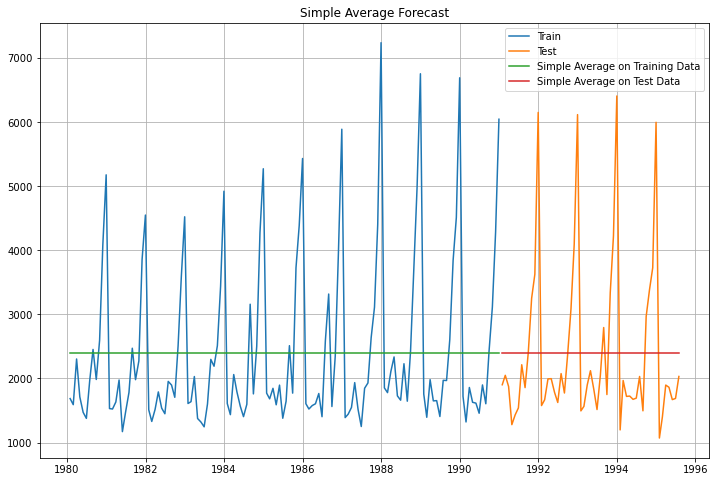

In [74]:
plt.figure(figsize=(12,8))
plt.plot(SimpleAverage_train['Sparkling'], label='Train')
plt.plot(SimpleAverage_test['Sparkling'], label='Test')
plt.plot(SimpleAverage_train['mean_forecast'], label='Simple Average on Training Data')
plt.plot(SimpleAverage_test['mean_forecast'], label='Simple Average on Test Data')
plt.legend(loc='best')
plt.title("Simple Average Forecast")
plt.grid();

### Model Evaluation

In [75]:
## Training Data - RMSE and MAPE

rmse_model6_train = metrics.mean_squared_error(train['Sparkling'],SimpleAverage_train['mean_forecast'],squared=False)
mape_model6_train = MAPE(train['Sparkling'],SimpleAverage_train['mean_forecast'])
print("For Simple Average Model forecast on the Training Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model6_train, mape_model6_train))

For Simple Average Model forecast on the Training Data,  RMSE is 1298.484 MAPE is 40.36


In [76]:
## Test Data - RMSE and MAPE

rmse_model6_test = metrics.mean_squared_error(test['Sparkling'],SimpleAverage_test['mean_forecast'],squared=False)
mape_model6_test = MAPE(test['Sparkling'],SimpleAverage_test['mean_forecast'])
print("For Simple Average forecast on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model6_test, mape_model6_test))

For Simple Average forecast on the Test Data,  RMSE is 1275.073 MAPE is 38.81


In [77]:
results6 = pd.DataFrame({'Test RMSE': [rmse_model6_test],'Test MAPE': [mape_model6_test]}
                           ,index=['SimpleAverageModel'])

results6

,Test RMSE,Test MAPE
SimpleAverageModel,1275.07338,38.81


In [78]:
resultsDf_6 = pd.concat([resultsDf_5, results6])
resultsDf_6

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15
NaiveModel,1327.156057,32.90
SimpleAverageModel,1275.073380,38.81


### Method 7: Moving Average Concept

In [79]:
MovingAverage = df1.copy()
MovingAverage.head()

,Sparkling
Time_Stamp,
1980-01-31,1686
1980-02-29,1591
1980-03-31,2304
1980-04-30,1712
1980-05-31,1471


In [80]:
MovingAverage['Trailing_2'] = MovingAverage['Sparkling'].rolling(2).mean()
MovingAverage['Trailing_4'] = MovingAverage['Sparkling'].rolling(4).mean()
MovingAverage['Trailing_6'] = MovingAverage['Sparkling'].rolling(6).mean()
MovingAverage['Trailing_9'] = MovingAverage['Sparkling'].rolling(9).mean()

MovingAverage.head()

,Sparkling,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1980-01-31,1686,NaN,NaN,NaN,NaN
1980-02-29,1591,1638.5,NaN,NaN,NaN
1980-03-31,2304,1947.5,NaN,NaN,NaN
1980-04-30,1712,2008.0,1823.25,NaN,NaN
1980-05-31,1471,1591.5,1769.50,NaN,NaN


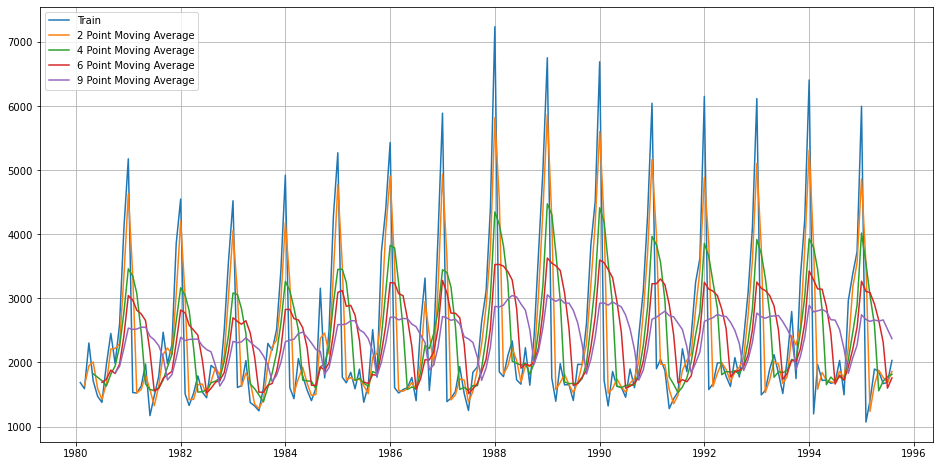

In [81]:
## Plotting on the whole data

plt.figure(figsize=(16,8))
plt.plot(MovingAverage['Sparkling'], label='Train')
plt.plot(MovingAverage['Trailing_2'], label='2 Point Moving Average')
plt.plot(MovingAverage['Trailing_4'], label='4 Point Moving Average')
plt.plot(MovingAverage['Trailing_6'],label = '6 Point Moving Average')
plt.plot(MovingAverage['Trailing_9'],label = '9 Point Moving Average')

plt.legend(loc = 'best')
plt.grid();

In [82]:
#Creating train and test set 
trailing_MovingAverage_train=MovingAverage[0:int(len(MovingAverage)*0.7)] 
trailing_MovingAverage_test=MovingAverage[int(len(MovingAverage)*0.7):]

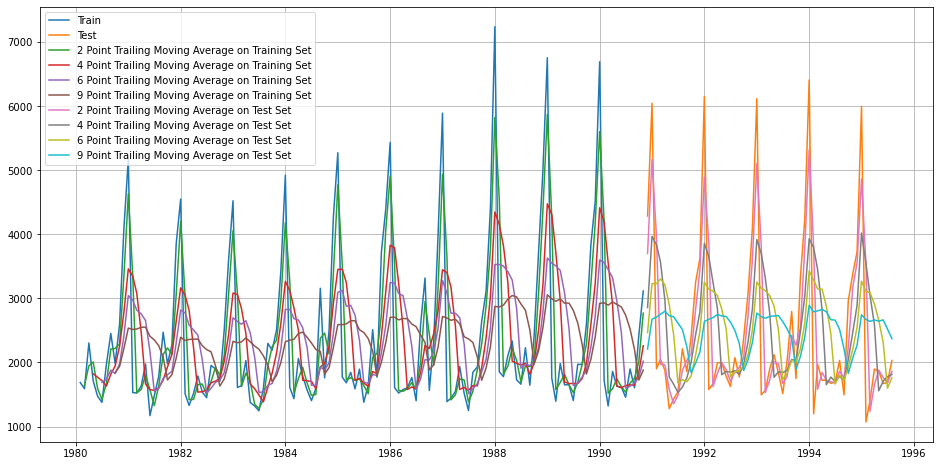

In [83]:
## Plotting on both the Training and Test data

plt.figure(figsize=(16,8))
plt.plot(trailing_MovingAverage_train['Sparkling'], label='Train')
plt.plot(trailing_MovingAverage_test['Sparkling'], label='Test')

plt.plot(trailing_MovingAverage_train['Trailing_2'], label='2 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_4'], label='4 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_6'],label = '6 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_9'],label = '9 Point Trailing Moving Average on Training Set')

plt.plot(trailing_MovingAverage_test['Trailing_2'], label='2 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_4'], label='4 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_6'],label = '6 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_9'],label = '9 Point Trailing Moving Average on Test Set')
plt.legend(loc = 'best')
plt.grid();

In [84]:
test.head()

,Sparkling
Time_Stamp,
1991-01-31,1902
1991-02-28,2049
1991-03-31,1874
1991-04-30,1279
1991-05-31,1432


In [85]:
trailing_MovingAverage_test.head()

,Sparkling,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1990-11-30,4286,3701.0,2857.75,2464.500000,2209.888889
1990-12-31,6047,5166.5,3968.25,3229.500000,2675.222222
1991-01-31,1902,3974.5,3837.75,3230.000000,2705.666667
1991-02-28,2049,1975.5,3571.00,3304.000000,2753.888889
1991-03-31,1874,1961.5,2968.00,3212.333333,2800.222222


In [86]:
trailing_MovingAverage_test[2:]

,Sparkling,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1991-01-31,1902,3974.5,3837.75,3230.000000,2705.666667
1991-02-28,2049,1975.5,3571.00,3304.000000,2753.888889
1991-03-31,1874,1961.5,2968.00,3212.333333,2800.222222
1991-04-30,1279,1576.5,1776.00,2906.166667,2731.333333
1991-05-31,1432,1355.5,1658.50,2430.500000,2712.111111
1991-06-30,1540,1486.0,1531.25,1679.333333,2613.888889
1991-07-31,2214,1877.0,1616.25,1731.333333,2513.666667
1991-08-31,1857,2035.5,1760.75,1699.333333,2243.777778
1991-09-30,2408,2132.5,2004.75,1788.333333,1839.444444


### Model Evaluation

In [87]:
## Test Data - RMSE and MAPE --> 2 point Trailing MA

rmse_model7_test_2 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_2'][2:],squared=False)
mape_model7_test_2 = MAPE(test['Sparkling'],trailing_MovingAverage_test['Trailing_2'][2:])
print("For 2 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_2, mape_model7_test_2))

## Test Data - RMSE and MAPE --> 4 point Trailing MA

rmse_model7_test_4 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_4'][2:],squared=False)
mape_model7_test_4 = MAPE(test['Sparkling'],trailing_MovingAverage_test['Trailing_4'][2:])
print("For 4 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_4, mape_model7_test_4))

## Test Data - RMSE and MAPE --> 6 point Trailing MA

rmse_model7_test_6 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_6'][2:],squared=False)
mape_model7_test_6 = MAPE(test['Sparkling'],trailing_MovingAverage_test['Trailing_6'][2:])
print("For 6 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_6, mape_model7_test_6))

## Test Data - RMSE and MAPE --> 9 point Trailing MA

rmse_model7_test_9 = metrics.mean_squared_error(test['Sparkling'],trailing_MovingAverage_test['Trailing_9'][2:],squared=False)
mape_model7_test_9 = MAPE(test['Sparkling'],trailing_MovingAverage_test['Trailing_9'][2:])
print("For 9 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_9, mape_model7_test_9))

For 2 point Moving Average Model forecast on the Testing Data,  RMSE is 813.401 MAPE is 19.70
For 4 point Moving Average Model forecast on the Testing Data,  RMSE is 1156.590 MAPE is 35.96
For 6 point Moving Average Model forecast on the Testing Data,  RMSE is 1283.927 MAPE is 43.86
For 9 point Moving Average Model forecast on the Testing Data,  RMSE is 1346.278 MAPE is 46.86


In [88]:
results7 = pd.DataFrame({'Test RMSE': [rmse_model7_test_2,rmse_model7_test_4
                                          ,rmse_model7_test_6,rmse_model7_test_9]
                            ,'Test MAPE': [mape_model7_test_2,mape_model7_test_4,mape_model7_test_6
                                           ,mape_model7_test_9]}
                           ,index=['2pointTrailingMovingAverage','4pointTrailingMovingAverage'
                                   ,'6pointTrailingMovingAverage','9pointTrailingMovingAverage'])

resultsDf_7 = pd.concat([resultsDf_6, results7])
resultsDf_7

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15
NaiveModel,1327.156057,32.90
SimpleAverageModel,1275.073380,38.81
2pointTrailingMovingAverage,813.400684,19.70
4pointTrailingMovingAverage,1156.589694,35.96
6pointTrailingMovingAverage,1283.927428,43.86


## 5. Check for the stationarity of the data on which the model is being built on using appropriate statistical tests and also mention the hypothesis for the statistical test. If the data is found to be non-stationary, take appropriate steps to make it stationary. Check the new data for stationarity and comment.
## Note: Stationarity should be checked at alpha = 0.05.

## Ans:

In [89]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=7).mean()
    rolstd = timeseries.rolling(window=7).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

### The Null Hypothesis: The data on which the model is being built is not stationary.
### The Alternate hypothesis: The data on which the model is being built is stationary.

### For this check, we will consider the p_value, and considering alpha = 0.05:
### if p_value is low - null hypothesis is rejected.
### if p_value is high - alternate hypothesis is rejected.

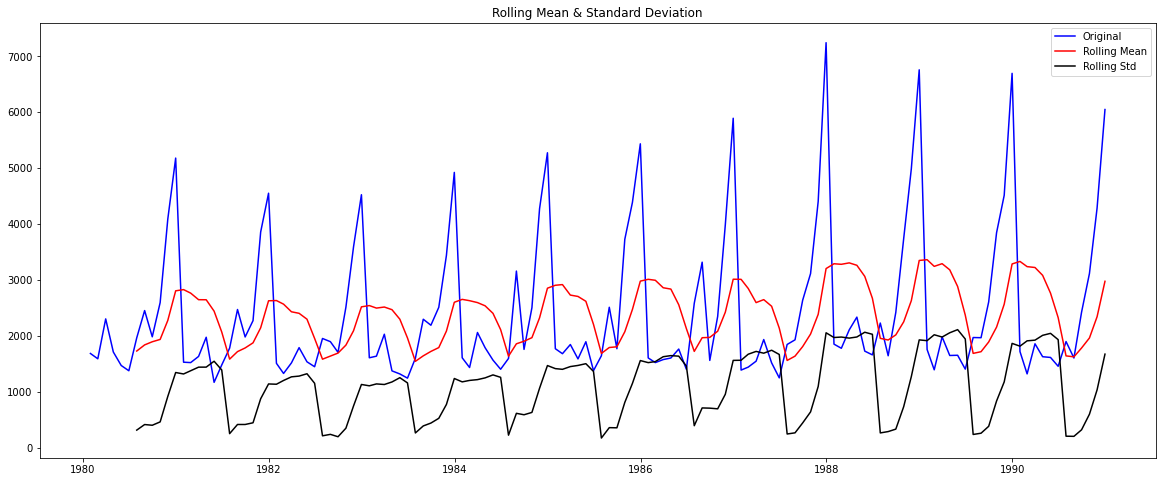

Results of Dickey-Fuller Test:
Test Statistic                  -1.208926
p-value                          0.669744
#Lags Used                      12.000000
Number of Observations Used    119.000000
Critical Value (1%)             -3.486535
Critical Value (5%)             -2.886151
Critical Value (10%)            -2.579896
dtype: float64 



In [90]:
test_stationarity(train['Sparkling'])

### Loking at above p_value, we see that the time series is not stationary at α = 0.05

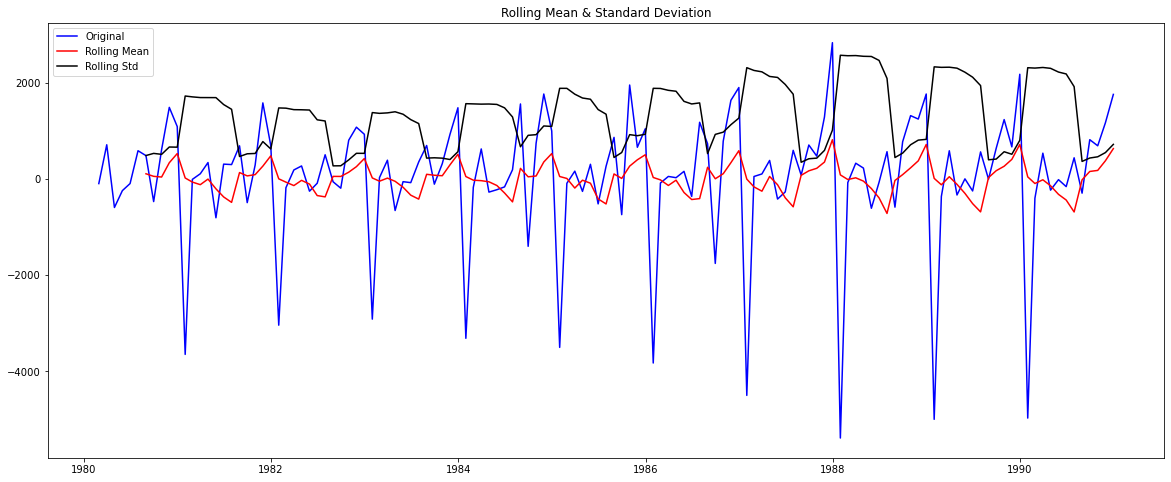

Results of Dickey-Fuller Test:
Test Statistic                -8.005007e+00
p-value                        2.280104e-12
#Lags Used                     1.100000e+01
Number of Observations Used    1.190000e+02
Critical Value (1%)           -3.486535e+00
Critical Value (5%)           -2.886151e+00
Critical Value (10%)          -2.579896e+00
dtype: float64 



In [91]:
test_stationarity(train['Sparkling'].diff().dropna())

### Looking at the above p_value, we see that after taking a difference of order 1 the time series have become stationary at α = 0.05

### Note: The series is non-stationary, we will stationarize the Time Series by taking a difference of the Time Series. Then we will use this particular differenced series to train the ARIMA models. We do not need to worry about stationarity for the Test Data because we are not building any models on the Test Data, we are evaluating our models over there.

## 6. Build an automated version of the ARIMA/SARIMA model in which the parameters are selected using the lowest Akaike Information Criteria (AIC) on the training data and evaluate this model on the test data using RMSE.

## Ans:

In [92]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = q = range(0, 3)
d= range(1,2)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)


In [93]:
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [94]:
from statsmodels.tsa.arima_model import ARIMA

for param in pdq:
    ARIMA_model = ARIMA(train['Sparkling'].values,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARIMA_AIC = ARIMA_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(0, 1, 0) - AIC:2269.582796371201
ARIMA(0, 1, 1) - AIC:2264.906437173329
ARIMA(0, 1, 2) - AIC:2232.783097684734
ARIMA(1, 1, 0) - AIC:2268.5280606863257
ARIMA(1, 1, 1) - AIC:2235.0139453501597
ARIMA(1, 1, 2) - AIC:2233.597647119585
ARIMA(2, 1, 0) - AIC:2262.035600081614
ARIMA(2, 1, 1) - AIC:2232.3604898890007
ARIMA(2, 1, 2) - AIC:2210.62306717763


C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\base\model.py:547: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warn('Inverting hessian failed, no bse or cov_params '


In [95]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
8,"(2, 1, 2)",2210.623067
7,"(2, 1, 1)",2232.360490
2,"(0, 1, 2)",2232.783098
5,"(1, 1, 2)",2233.597647
4,"(1, 1, 1)",2235.013945
6,"(2, 1, 0)",2262.035600
1,"(0, 1, 1)",2264.906437
3,"(1, 1, 0)",2268.528061
0,"(0, 1, 0)",2269.582796


In [96]:
auto_ARIMA = ARIMA(train['Sparkling'], order=(2,1,2),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

                             ARIMA Model Results                              
Dep. Variable:            D.Sparkling   No. Observations:                  131
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -1099.312
Method:                       css-mle   S.D. of innovations           1013.526
Date:                Thu, 26 Jun 2025   AIC                           2210.623
Time:                        13:49:56   BIC                           2227.874
Sample:                    02-29-1980   HQIC                          2217.633
                         - 12-31-1990                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.5837      0.519     10.757      0.000       4.566       6.601
ar.L1.D.Sparkling     1.2699      0.075     17.042      0.000       1.124       1.416
ar.L2.D.Sparkling    -0.

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\base\model.py:547: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warn('Inverting hessian failed, no bse or cov_params '


### Predict on the Test Set using this model and evaluate the model

In [97]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

In [98]:
from sklearn.metrics import  mean_squared_error
rmse = mean_squared_error(test['Sparkling'],predicted_auto_ARIMA[0],squared=False)
print(rmse)

1374.1109222333473


In [99]:
rmse_model8_test = metrics.mean_squared_error(test['Sparkling'],predicted_auto_ARIMA[0],squared=False)
mape_model8_test = MAPE(test['Sparkling'],predicted_auto_ARIMA[0])
print("For Automated Version of ARIMA/SARIMA using Lowest AIC on the training data and evaluating on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model8_test, mape_model8_test))

For Automated Version of ARIMA/SARIMA using Lowest AIC on the training data and evaluating on the Test Data,  RMSE is 1374.111 MAPE is 48.33


In [100]:
results8 = pd.DataFrame({'Test RMSE': [rmse_model8_test],'Test MAPE': [mape_model8_test]}
                           ,index=[' Auto ARIMA (2,1,2)'])

results8

,Test RMSE,Test MAPE
"Auto ARIMA (2,1,2)",1374.110922,48.33


In [101]:
resultsDf_8 = pd.concat([resultsDf_7, results8])
resultsDf_8

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15
NaiveModel,1327.156057,32.90
SimpleAverageModel,1275.073380,38.81
2pointTrailingMovingAverage,813.400684,19.70
4pointTrailingMovingAverage,1156.589694,35.96
6pointTrailingMovingAverage,1283.927428,43.86


## 7. Build ARIMA/SARIMA models based on the cut-off points of ACF and PACF on the training data and evaluate this model on the test data using RMSE.

## Ans:

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\regression\linear_model.py:1406: RuntimeWarning: invalid value encountered in sqrt
  return rho, np.sqrt(sigmasq)


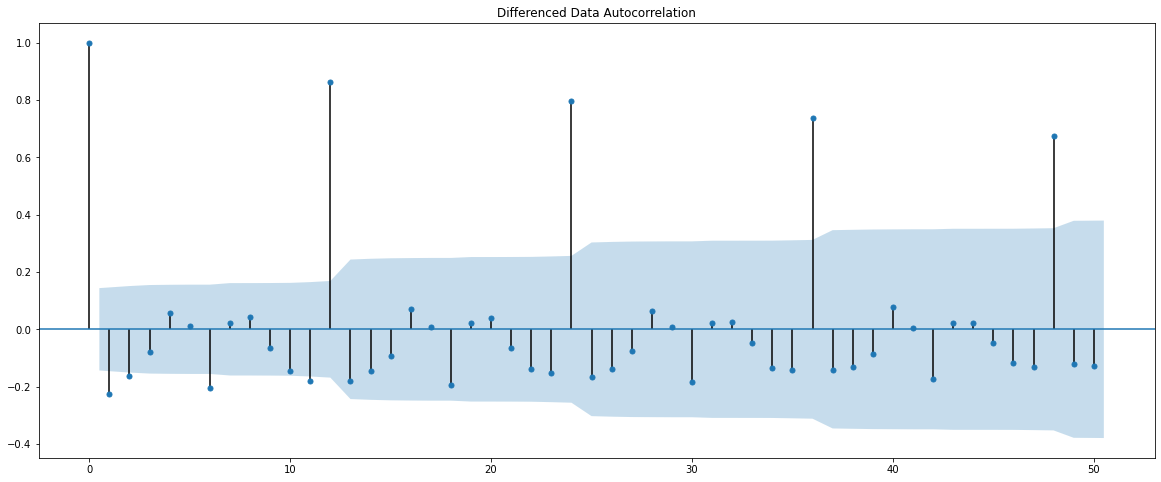

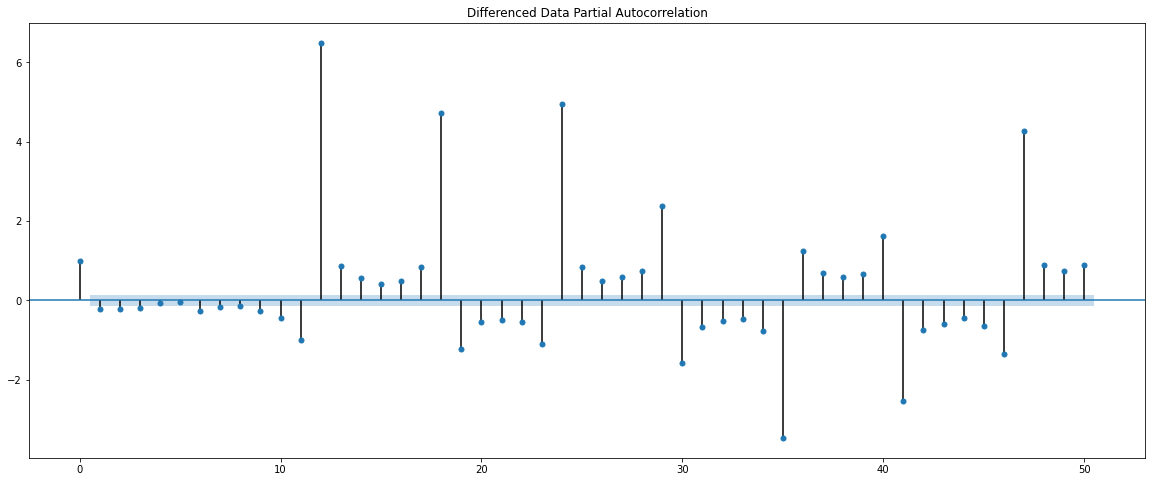

In [102]:
plot_acf(df1['Sparkling'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plot_pacf(df1['Sparkling'].diff().dropna(),lags=50,title='Differenced Data Partial Autocorrelation')
plt.show()

### The Auto-Regressive parameter in an ARIMA model is 'p' which comes from the lag at which the PACF plot cuts-off to 0 which is 3.
### The Moving-Average parameter in an ARIMA model is 'q' which comes from the lag at which the ACF plot cuts-off to 0 which is 2.

In [103]:
manual_ARIMA = ARIMA(train['Sparkling'], order=(3,1,2),freq='M')

results_manual_ARIMA = manual_ARIMA.fit()

print(results_manual_ARIMA.summary())

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\base\model.py:547: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warn('Inverting hessian failed, no bse or cov_params '
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\arima_model.py:1490: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(-inv(hess)))
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)


                             ARIMA Model Results                              
Dep. Variable:            D.Sparkling   No. Observations:                  131
Model:                 ARIMA(3, 1, 2)   Log Likelihood               -1107.464
Method:                       css-mle   S.D. of innovations           1106.081
Date:                Thu, 26 Jun 2025   AIC                           2228.927
Time:                        13:49:59   BIC                           2249.054
Sample:                    02-29-1980   HQIC                          2237.106
                         - 12-31-1990                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.9843        nan        nan        nan         nan         nan
ar.L1.D.Sparkling    -0.4419        nan        nan        nan         nan         nan
ar.L2.D.Sparkling     0.

### Predict on the Test Set using this model and evaluate the model.

In [104]:
predicted_manual_ARIMA = results_manual_ARIMA.forecast(steps=len(test))

In [105]:
rmse_model9_test = metrics.mean_squared_error(test['Sparkling'],predicted_manual_ARIMA[0],squared=False)
mape_model9_test = MAPE(test['Sparkling'],predicted_manual_ARIMA[0])
print("For Manual Version of ARIMA/SARIMA using ACF/PACF and evaluating on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model9_test, mape_model9_test))

For Manual Version of ARIMA/SARIMA using ACF/PACF and evaluating on the Test Data,  RMSE is 1378.948 MAPE is 49.31


In [106]:
results9 = pd.DataFrame({'Test RMSE': [rmse_model9_test],'Test MAPE': [mape_model9_test]}
                           ,index=[' Manual ARIMA (3,1,2)'])

results9

,Test RMSE,Test MAPE
"Manual ARIMA (3,1,2)",1378.947728,49.31


In [107]:
resultsDf_9 = pd.concat([resultsDf_8, results9])
resultsDf_9

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15
NaiveModel,1327.156057,32.90
SimpleAverageModel,1275.073380,38.81
2pointTrailingMovingAverage,813.400684,19.70
4pointTrailingMovingAverage,1156.589694,35.96
6pointTrailingMovingAverage,1283.927428,43.86


## 8. Build a table with all the models built along with their corresponding parameters and the respective RMSE values on the test data.

## Ans:

In [108]:
resultsDf_9

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66
"Alpha=0.4,SimpleExponentialSmoothing",2311.919615,91.55
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",18259.110704,675.28
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",1935.507132,75.66
RegressionOnTime,1389.135175,50.15
NaiveModel,1327.156057,32.90
SimpleAverageModel,1275.073380,38.81
2pointTrailingMovingAverage,813.400684,19.70
4pointTrailingMovingAverage,1156.589694,35.96
6pointTrailingMovingAverage,1283.927428,43.86


### The above table represents all the Models with their respective Test RMSE and Test MAPE values.

In [109]:
resultsDf_9.sort_values(by='Test RMSE',ascending=True)

,Test RMSE,Test MAPE
2pointTrailingMovingAverage,813.400684,19.70
4pointTrailingMovingAverage,1156.589694,35.96
SimpleAverageModel,1275.073380,38.81
6pointTrailingMovingAverage,1283.927428,43.86
NaiveModel,1327.156057,32.90
9pointTrailingMovingAverage,1346.278315,46.86
"Auto ARIMA (2,1,2)",1374.110922,48.33
"Manual ARIMA (3,1,2)",1378.947728,49.31
RegressionOnTime,1389.135175,50.15
"Alpha=0.3,SimpleExponentialSmoothing",1935.507132,75.66


### The above table represents all the Models sorted by the lowest Test RMSE.

## 9. Based on the model-building exercise, build the most optimum model(s) on the complete data and predict 12 months into the future with appropriate confidence intervals/bands.

## Ans:

### From the above table, we can observe that the Trailing Moving Average have a lower Test RMSE and in specific, the 2point Trailing Moving Average has the least Test RMSE.
### If we keep aside the concept of Moving Average, we can find that the Auto ARIMA has the next best Test RMSE value.
### Infact, the above inference also holds good with respect to Test MAPE values.

In [110]:
import statsmodels.api as sm

In [111]:
full_data_model = sm.tsa.statespace.SARIMAX(df1['Sparkling'],
                                order=(2,1,2),
                                seasonal_order=None,
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_full_data_model = full_data_model.fit(maxiter=1000)
print(results_full_data_model.summary())

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


                               SARIMAX Results                                
Dep. Variable:              Sparkling   No. Observations:                  187
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -1561.536
Date:                Thu, 26 Jun 2025   AIC                           3133.072
Time:                        13:50:03   BIC                           3149.120
Sample:                    01-31-1980   HQIC                          3139.577
                         - 07-31-1995                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5945      0.100     -5.923      0.000      -0.791      -0.398
ar.L2          0.4079      0.099      4.101      0.000       0.213       0.603
ma.L1          0.0020      0.181      0.011      0.9

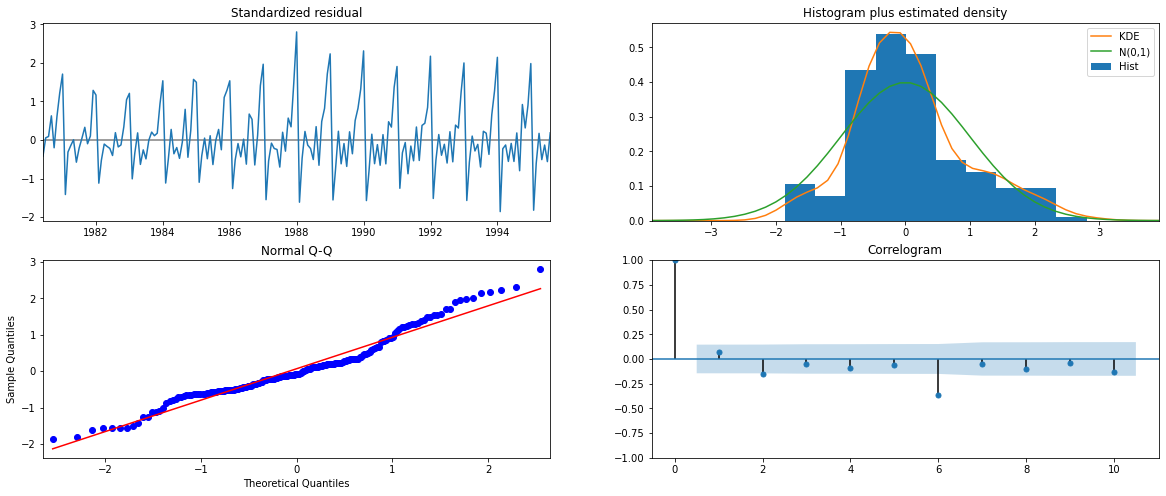

In [112]:
results_full_data_model.plot_diagnostics();

In [113]:
predicted_auto_ARIMA_full_data = results_full_data_model.get_forecast(steps=12)

In [114]:
predicted_auto_ARIMA_full_data.summary_frame(alpha=0.05).head()

Sparkling,mean,mean_se,mean_ci_lower,mean_ci_upper
1995-08-31,2594.730542,1375.870492,-101.926069,5291.387153
1995-09-30,2148.366455,1485.372810,-762.910756,5059.643666
1995-10-31,2643.675841,1506.338704,-308.693768,5596.045450
1995-11-30,2167.146356,1509.743080,-791.895706,5126.188418
1995-12-31,2652.477643,1511.052860,-309.131542,5614.086827


In [115]:
pred_full_auto_ARIMA_date = predicted_auto_ARIMA_full_data.summary_frame(alpha=0.05).set_index(pd.date_range(start='1995-08-31',end='1996-07-31', freq='M'))

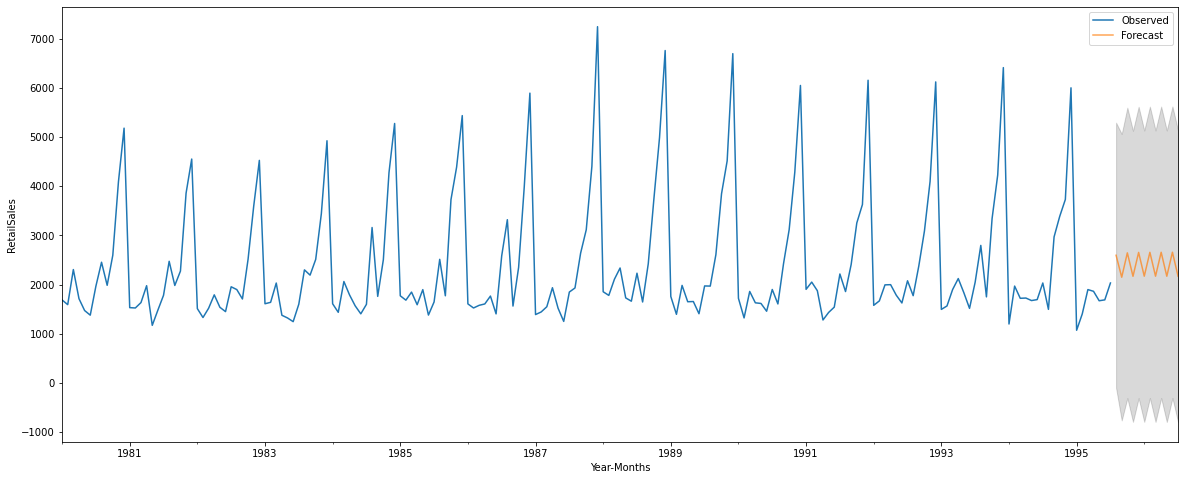

In [116]:
# plot the forecast along with the confidence band

axis = df1['Sparkling'].plot(label='Observed')
pred_full_auto_ARIMA_date['mean'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(pred_full_auto_ARIMA_date.index, pred_full_auto_ARIMA_date['mean_ci_lower'], 
                  pred_full_auto_ARIMA_date['mean_ci_upper'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('RetailSales')
plt.legend(loc='best')
plt.show()

In [117]:
pred_full_auto_ARIMA_date['mean']

1995-08-31    2594.730542
1995-09-30    2148.366455
1995-10-31    2643.675841
1995-11-30    2167.146356
1995-12-31    2652.477643
1996-01-31    2169.574691
1996-02-29    2654.624525
1996-03-31    2169.289004
1996-04-30    2655.670120
1996-05-31    2168.550890
1996-06-30    2656.535430
1996-07-31    2167.735394
Freq: M, Name: mean, dtype: float64

### The above table represents the Forecast for nest 12 months using the ARIMA approach.

In [118]:
MovingAverage_model_future = df1.copy()

In [119]:
MovingAverage_model_future.tail()

,Sparkling
Time_Stamp,
1995-03-31,1897
1995-04-30,1862
1995-05-31,1670
1995-06-30,1688
1995-07-31,2031


In [120]:
Month = pd.date_range(start='8/31/1995', end='7/31/1996', freq='M')

In [121]:
Month

DatetimeIndex(['1995-08-31', '1995-09-30', '1995-10-31', '1995-11-30',
               '1995-12-31', '1996-01-31', '1996-02-29', '1996-03-31',
               '1996-04-30', '1996-05-31', '1996-06-30', '1996-07-31'],
              dtype='datetime64[ns]', freq='M')

In [122]:
MovingAverage_model_future[-2:]

,Sparkling
Time_Stamp,
1995-06-30,1688
1995-07-31,2031


In [123]:
first_month_prediction = MovingAverage_model_future['Sparkling'][-2:].mean()
first_month_prediction

1859.5

In [124]:
second_month_prediction = (first_month_prediction + MovingAverage_model_future['Sparkling'][-1:]).mean()
second_month_prediction

3890.5

In [125]:
predictions = [first_month_prediction, second_month_prediction, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
predictions

[1859.5, 3890.5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [126]:
for i in np.arange(0,10,1):
    predictions[i+2] = (predictions[i] + predictions[i+1])/2

In [127]:
predictions

[1859.5,
 3890.5,
 2875.0,
 3382.75,
 3128.875,
 3255.8125,
 3192.34375,
 3224.078125,
 3208.2109375,
 3216.14453125,
 3212.177734375,
 3214.1611328125]

In [128]:
Future_Predictions = pd.DataFrame({'Month':Month, 'Predictions_MA_2':predictions})

In [129]:
Future_Predictions

,Month,Predictions_MA_2
0,1995-08-31,1859.500000
1,1995-09-30,3890.500000
2,1995-10-31,2875.000000
3,1995-11-30,3382.750000
4,1995-12-31,3128.875000
5,1996-01-31,3255.812500
6,1996-02-29,3192.343750
7,1996-03-31,3224.078125
8,1996-04-30,3208.210938
9,1996-05-31,3216.144531


### The above table represents the Forecast for nest 12 months using the 2point trailing moving approach.

## 10. Comment on the model thus built and report your findings and suggest the measures that the company should be taking for future sales.

### From the above developed models, we can observe that the Moving Average Model performs better when compared to other models with respect to Test RMSE values being the least.
### We can also observe that, in terms of MAPE values as well, the Moving Average Model is performing better compared to other models.
### It can be noted that, the ARIMA model has performed better compared to the Logistic Regression model with respect to both Test RMSE and Test MAPE.
### From the Time series plot we can observe that the Sparkling Wine sales have an increasing trend initially until 1988 and then the trend seems to be slightly decreasing as the year goes by.
### From the monthly plot, we can observe that the sale have an increasing trend starting from August and achieves a peak sales in the month of December. The reason for increase in sales could be due to Christmas season.
### However, the sales reaching the peak in the month of December is just a slight increase when compared to other months.
### It is recommended that the company needs to better market their products to beat the competitors and hit the highest peak possible during this season when the overall sales increases which is usually during the end of the year.
### As there is a downfall after 1988, the company needs to think of the impact which has caused this downfall and also required to think of what the people are preferring over the wine.

# Part 2: Data set Rose.csv

## 1. Read the data as an appropriate Time Series data and plot the data.

## Ans:

In [130]:
df2 = pd.read_csv('Rose.csv')

In [131]:
df2.head()

,YearMonth,Rose
0,1980-01,112.0
1,1980-02,118.0
2,1980-03,129.0
3,1980-04,99.0
4,1980-05,116.0


In [132]:
df2.tail()

,YearMonth,Rose
182,1995-03,45.0
183,1995-04,52.0
184,1995-05,28.0
185,1995-06,40.0
186,1995-07,62.0


In [133]:
df2.shape

(187, 2)

### Creating the Time Stamps and adding to the data frame to make it a Time Series Data

In [134]:
date2 = pd.date_range(start='1/01/1980', end= '7/31/1995', freq='M')
date2

DatetimeIndex(['1980-01-31', '1980-02-29', '1980-03-31', '1980-04-30',
               '1980-05-31', '1980-06-30', '1980-07-31', '1980-08-31',
               '1980-09-30', '1980-10-31',
               ...
               '1994-10-31', '1994-11-30', '1994-12-31', '1995-01-31',
               '1995-02-28', '1995-03-31', '1995-04-30', '1995-05-31',
               '1995-06-30', '1995-07-31'],
              dtype='datetime64[ns]', length=187, freq='M')

In [135]:
df2['Time_Stamp'] = pd.DataFrame(date2)
df2.head()

,YearMonth,Rose,Time_Stamp
0,1980-01,112.0,1980-01-31
1,1980-02,118.0,1980-02-29
2,1980-03,129.0,1980-03-31
3,1980-04,99.0,1980-04-30
4,1980-05,116.0,1980-05-31


In [136]:
df2.set_index('Time_Stamp',inplace=True)
df2.head()

,YearMonth,Rose
Time_Stamp,,
1980-01-31,1980-01,112.0
1980-02-29,1980-02,118.0
1980-03-31,1980-03,129.0
1980-04-30,1980-04,99.0
1980-05-31,1980-05,116.0


In [137]:
df2.drop("YearMonth", axis = 1, inplace = True)
df2.head()

,Rose
Time_Stamp,
1980-01-31,112.0
1980-02-29,118.0
1980-03-31,129.0
1980-04-30,99.0
1980-05-31,116.0


### Plot the Time Series to understand the behaviour of the data

In [138]:
rcParams['figure.figsize'] = 20,8

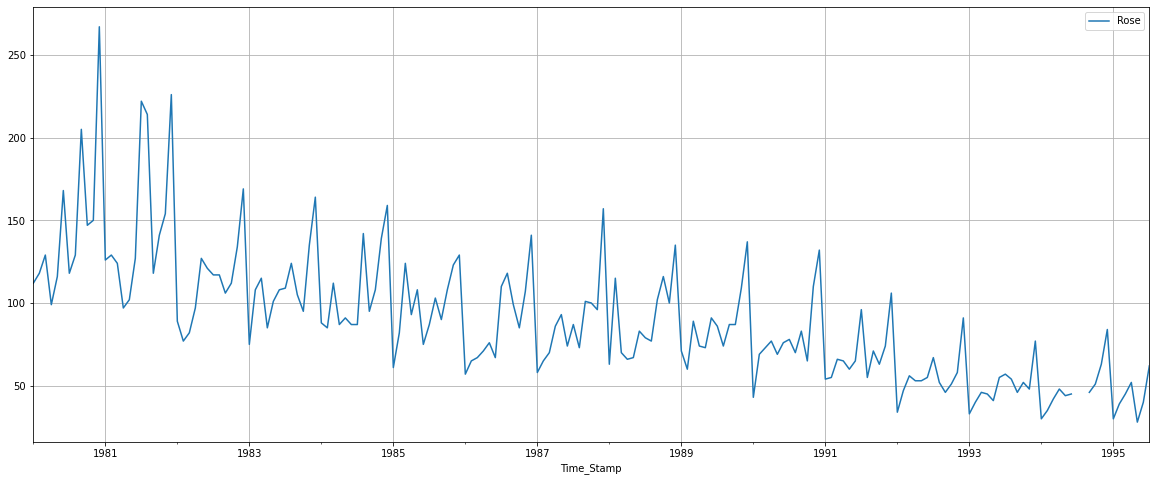

In [139]:
df2.plot()
plt.grid();

## 2. Perform appropriate Exploratory Data Analysis to understand the data and also perform decomposition.

## Ans:

### Check the basic measures of descriptive statistics

In [140]:
df2.describe()

,Rose
count,185.000000
mean,90.394595
std,39.175344
min,28.000000
25%,63.000000
50%,86.000000
75%,112.000000
max,267.000000


### Plot a boxplot to understand the spread of sales across different years and within different months across years.

### Yearly Plot

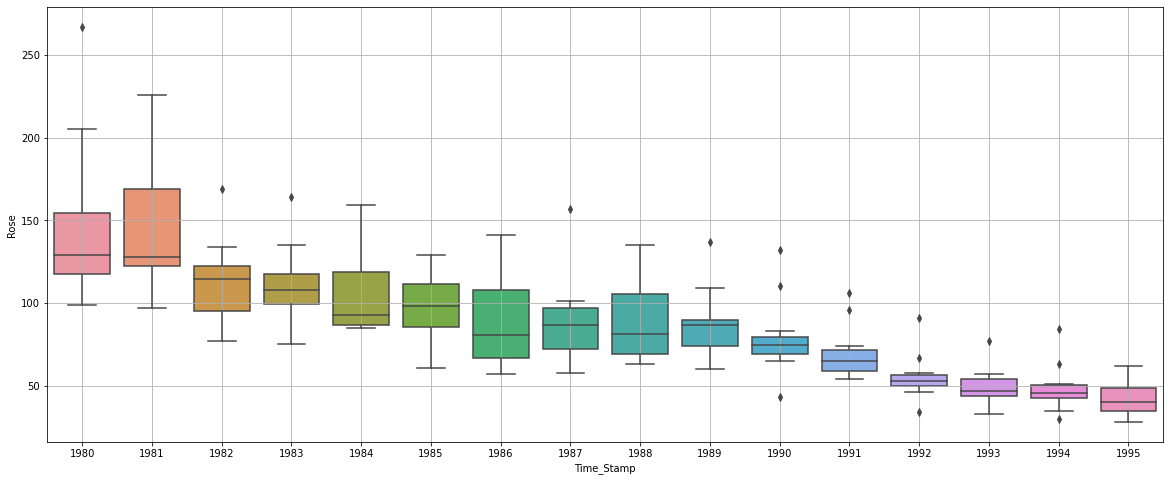

In [141]:
sns.boxplot(x = df2.index.year,y = df2['Rose'])
plt.grid();

### Monthly Plot

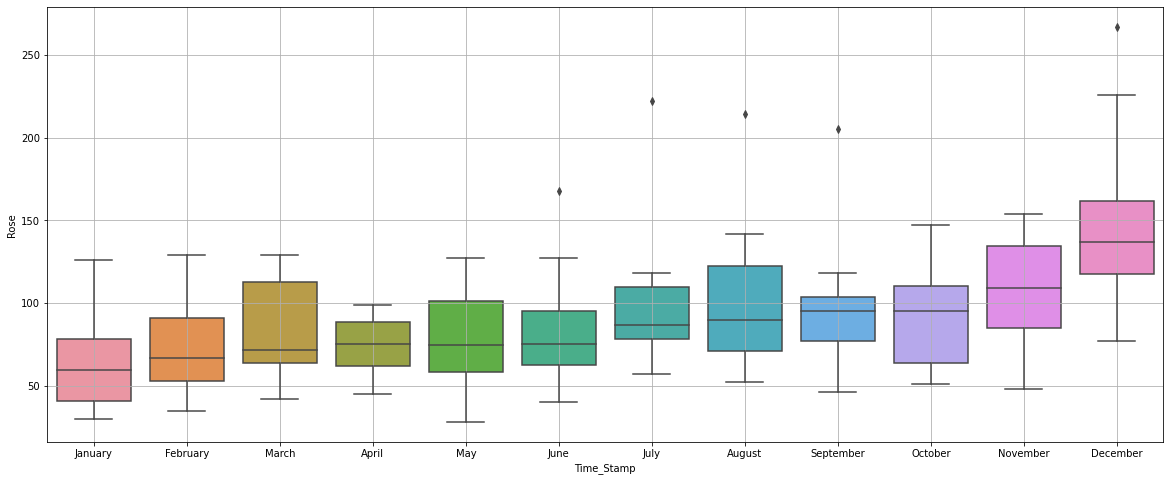

In [142]:
sns.boxplot(x = df2.index.month_name(),y = df2['Rose'])
plt.grid();

### Plot a time series monthplot to understand the sales of accidents across different years and within different months across years

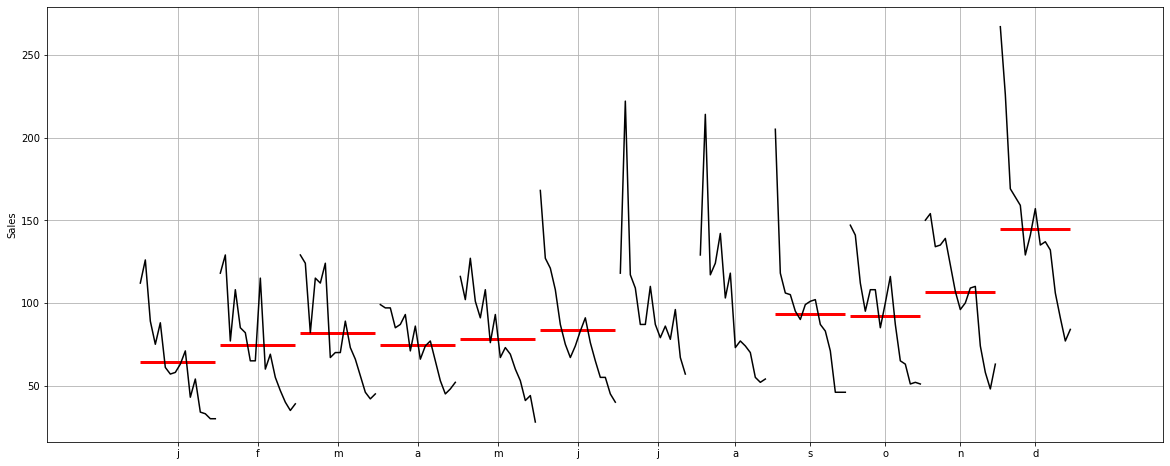

In [143]:
month_plot(df2['Rose'],ylabel='Sales')
plt.grid();

### Plot a graph of monthly sales across years

In [144]:
monthly_sales_across_years2 = pd.pivot_table(df2, values = 'Rose', columns = df2.index.month, index = df2.index.year)
monthly_sales_across_years2

Time_Stamp,1,2,3,4,5,6,7,8,9,10,11,12
Time_Stamp,,,,,,,,,,,,
1980,112.0,118.0,129.0,99.0,116.0,168.0,118.0,129.0,205.0,147.0,150.0,267.0
1981,126.0,129.0,124.0,97.0,102.0,127.0,222.0,214.0,118.0,141.0,154.0,226.0
1982,89.0,77.0,82.0,97.0,127.0,121.0,117.0,117.0,106.0,112.0,134.0,169.0
1983,75.0,108.0,115.0,85.0,101.0,108.0,109.0,124.0,105.0,95.0,135.0,164.0
1984,88.0,85.0,112.0,87.0,91.0,87.0,87.0,142.0,95.0,108.0,139.0,159.0
1985,61.0,82.0,124.0,93.0,108.0,75.0,87.0,103.0,90.0,108.0,123.0,129.0
1986,57.0,65.0,67.0,71.0,76.0,67.0,110.0,118.0,99.0,85.0,107.0,141.0
1987,58.0,65.0,70.0,86.0,93.0,74.0,87.0,73.0,101.0,100.0,96.0,157.0
1988,63.0,115.0,70.0,66.0,67.0,83.0,79.0,77.0,102.0,116.0,100.0,135.0


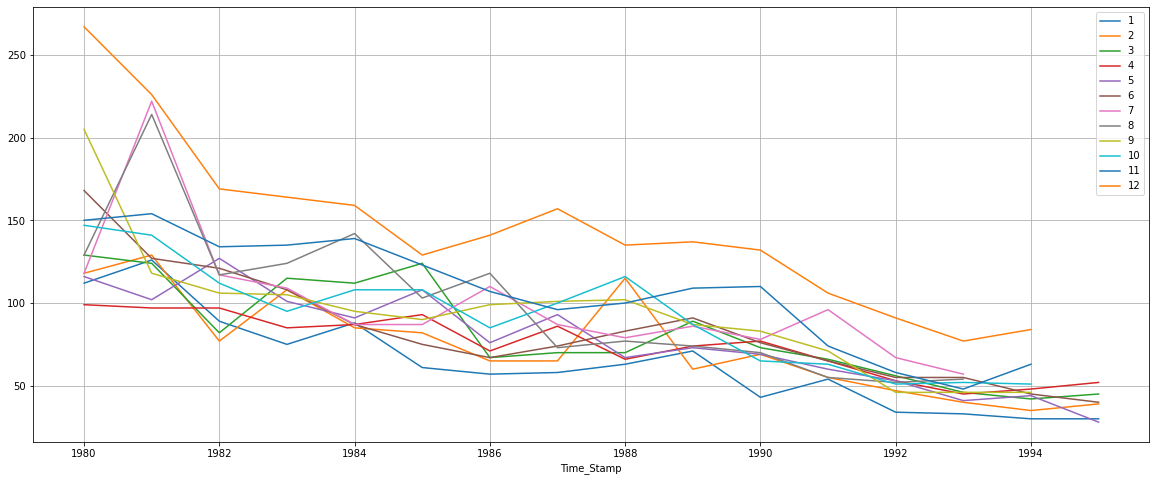

In [145]:
monthly_sales_across_years2.plot()
plt.grid()
plt.legend(loc='best');

### Plot the Empirical Cumulative Distribution

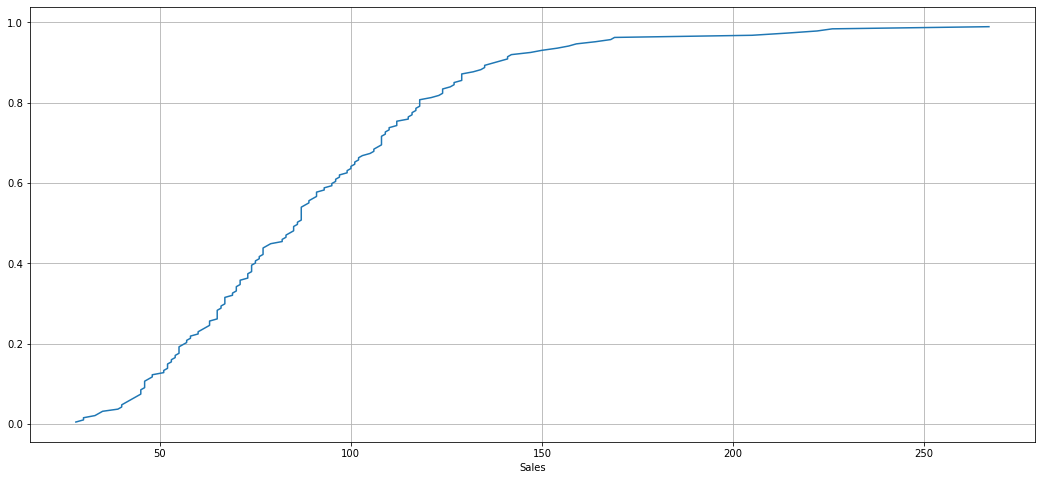

In [146]:
plt.figure(figsize = (18, 8))
cdf = ECDF(df2['Rose'])
plt.plot(cdf.x, cdf.y, label = "statmodels");
plt.grid()
plt.xlabel('Sales');

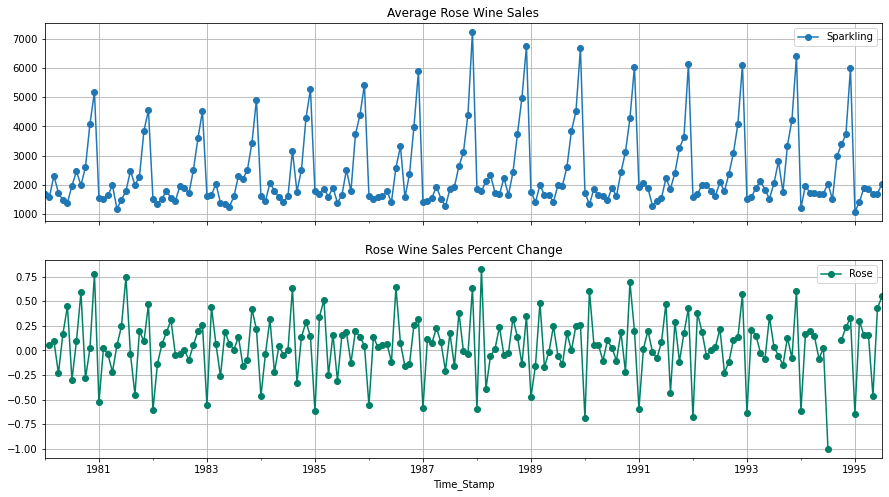

In [147]:
### Plot the average Rose Wine Sales per month and the month on month percentage change of Sales.average    = df2.groupby(df2.index)["Rose"].mean()
pct_change = df2.groupby(df2.index)["Rose"].sum().pct_change()

fig, (axis1,axis2) = plt.subplots(2,1,sharex=True,figsize=(15,8))

# plot average Rose Wine Sales over time(year-month)
ax1 = average.plot(legend=True,ax=axis1,marker='o',title="Average Rose Wine Sales",grid=True)
ax1.set_xticks(range(len(average)))
ax1.set_xticklabels(average.index.tolist())
# plot precent change for Rose Wine Sales over time(year-month)
ax2 = pct_change.plot(legend=True,ax=axis2,marker='o',colormap="summer",title="Rose Wine Sales Percent Change",grid=True)

### Decompose the Time Series and plot the different components.

In [148]:
df2.Rose.isnull().sum()

2

In [149]:
df2[df2.Rose.isnull()]

,Rose
Time_Stamp,
1994-07-31,NaN
1994-08-31,NaN


In [150]:
df2[df2.index.year >= 1994].head(10)

,Rose
Time_Stamp,
1994-01-31,30.0
1994-02-28,35.0
1994-03-31,42.0
1994-04-30,48.0
1994-05-31,44.0
1994-06-30,45.0
1994-07-31,NaN
1994-08-31,NaN
1994-09-30,46.0


### Replacing Null values with the previous value, ie., 45

In [151]:
df2.Rose.fillna(45, inplace = True)

In [152]:
df2.Rose.isnull().sum()

0

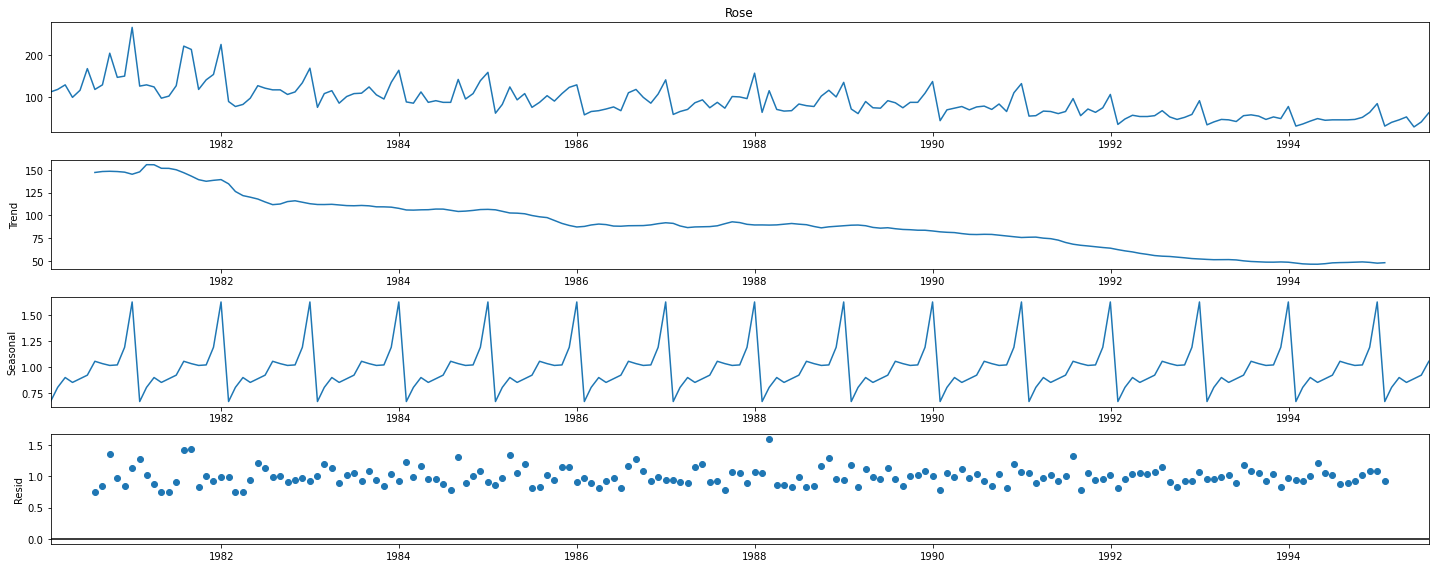

In [153]:
decomposition = seasonal_decompose(df2['Rose'],model='multiplicative')
decomposition.plot();

## 3. Split the data into training and test. The test data should start in 1991.

## Ans:

In [154]:
train=df2[df2.index.year < 1991]
test=df2[df2.index.year >= 1991]

In [155]:
print('First few rows of Training Data')
display(train.head())
print('Last few rows of Training Data')
display(train.tail())
print('First few rows of Test Data')
display(test.head())
print('Last few rows of Test Data')
display(test.tail())

First few rows of Training Data


,Rose
Time_Stamp,
1980-01-31,112.0
1980-02-29,118.0
1980-03-31,129.0
1980-04-30,99.0
1980-05-31,116.0


Last few rows of Training Data


,Rose
Time_Stamp,
1990-08-31,70.0
1990-09-30,83.0
1990-10-31,65.0
1990-11-30,110.0
1990-12-31,132.0


First few rows of Test Data


,Rose
Time_Stamp,
1991-01-31,54.0
1991-02-28,55.0
1991-03-31,66.0
1991-04-30,65.0
1991-05-31,60.0


Last few rows of Test Data


,Rose
Time_Stamp,
1995-03-31,45.0
1995-04-30,52.0
1995-05-31,28.0
1995-06-30,40.0
1995-07-31,62.0


In [156]:
print(train.shape)
print(test.shape)

(132, 1)
(55, 1)


## 4. Build various exponential smoothing models on the training data and evaluate the model using RMSE on the test data.
## Other models such as regression,naïve forecast models, simple average models etc. should also be built on the training data and check the performance on the test data using RMSE.

## Ans:

In [157]:
## Mean Absolute Percentage - Function Definition

def MAPE(y, yhat): 
    y, yhat = np.array(y), np.array(yhat)
    try:
        mape =  round(np.sum(np.abs(yhat - y)) / np.sum(y) * 100,2)
    except:
        print("Observed values are empty")
        mape = np.nan
    return mape

### Method 1: Simple Exponential Smoothing

In [158]:
SES_train = train.copy()
SES_test = test.copy()

In [159]:
model_SES = SimpleExpSmoothing(SES_train['Rose'])

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


### Model Evaluation

In [160]:
results = pd.DataFrame({'Alpha Values':[],'Train RMSE':[],'Train MAPE':[]
                                ,'Test RMSE': [],'Test MAPE': []})
results

,Alpha Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE


In [161]:
for i in np.arange(0.3,1,0.1):
    model_SES_alpha_i = model_SES.fit(smoothing_level=i,optimized=True,use_brute=True)
    SES_train['predict',i] = model_SES_alpha_i.fittedvalues
    SES_test['predict',i] = model_SES_alpha_i.forecast(steps=55)
    
    rmse_model1_train_i = metrics.mean_squared_error(SES_train['Rose'],SES_train['predict',i],squared=False)
    mape_model1_train_i = MAPE(SES_train['Rose'],SES_train['predict',i])
    
    rmse_model1_test_i = metrics.mean_squared_error(SES_test['Rose'],SES_test['predict',i],squared=False)
    mape_model1_test_i = MAPE(SES_test['Rose'],SES_test['predict',i])
    
    results = results.append({'Alpha Values':i,'Train RMSE':rmse_model1_train_i 
                                      ,'Train MAPE': mape_model1_train_i,'Test RMSE':rmse_model1_test_i
                                      ,'Test MAPE':mape_model1_test_i}, ignore_index=True)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

In [162]:
results

,Alpha Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,32.448833,22.31,47.525251,83.77
1,0.4,33.028400,22.51,53.787686,95.57
2,0.5,33.680192,22.69,59.661932,106.88
3,0.6,34.439946,22.89,64.991324,117.11
4,0.7,35.322683,23.09,69.718108,126.14
5,0.8,36.334371,23.42,73.793865,133.90
6,0.9,37.482735,23.93,77.159094,140.30


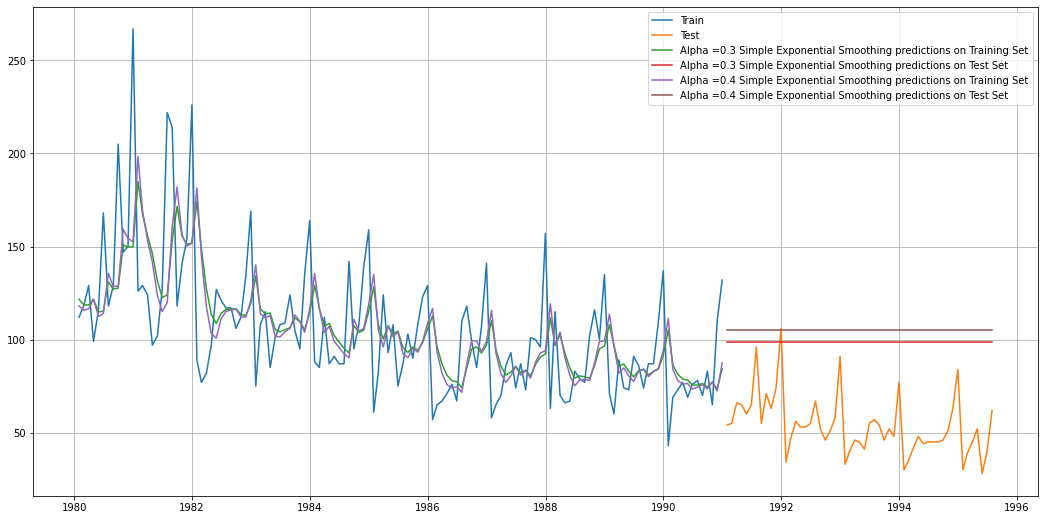

In [163]:
plt.figure(figsize=(18,9))
plt.plot(SES_train['Rose'], label='Train')
plt.plot(SES_test['Rose'], label='Test')

plt.plot(SES_train['predict', 0.3], label='Alpha =0.3 Simple Exponential Smoothing predictions on Training Set')
plt.plot(SES_test['predict', 0.3], label='Alpha =0.3 Simple Exponential Smoothing predictions on Test Set')

plt.plot(SES_train['predict', 0.4], label='Alpha =0.4 Simple Exponential Smoothing predictions on Training Set')
plt.plot(SES_test['predict', 0.4], label='Alpha =0.4 Simple Exponential Smoothing predictions on Test Set')


plt.legend(loc='best')
plt.grid();

In [164]:
resultsDf = pd.DataFrame({'Test RMSE': [results['Test RMSE'][0],results['Test RMSE'][1]]
                            ,'Test MAPE': [results['Test MAPE'][0],results['Test MAPE'][1]]}
                           ,index=['Alpha=0.3,SimpleExponentialSmoothing','Alpha=0.4,SimpleExponentialSmoothing'])

resultsDf

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57


### Method 2: Double Exponential Smoothing

In [165]:
DES_train = train.copy()
DES_test = test.copy()

In [166]:
model_DES = Holt(DES_train['Rose'])

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


### Model Evaluation

In [167]:
resultsDf_1 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Train RMSE':[],'Train MAPE':[]
                                ,'Test RMSE': [],'Test MAPE': []})
resultsDf_1

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE


In [168]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        model_DES_alpha_i_j = model_DES.fit(smoothing_level=i,smoothing_slope=j,optimized=True,use_brute=True)
        DES_train['predict',i,j] = model_DES_alpha_i_j.fittedvalues
        DES_test['predict',i,j] = model_DES_alpha_i_j.forecast(steps=55)
        
        rmse_model2_train = metrics.mean_squared_error(DES_train['Rose'],DES_train['predict',i,j],squared=False)
        mape_model2_train = MAPE(DES_train['Rose'],DES_train['predict',i,j])
        
        rmse_model2_test = metrics.mean_squared_error(DES_test['Rose'],DES_test['predict',i,j],squared=False)
        mape_model2_test = MAPE(DES_test['Rose'],DES_test['predict',i,j])
        
        resultsDf_1 = resultsDf_1.append({'Alpha Values':i,'Beta Values':j,'Train RMSE':rmse_model2_train
                                      ,'Train MAPE': mape_model2_train,'Test RMSE':rmse_model2_test
                                      ,'Test MAPE':mape_model2_test}, ignore_index=True)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

In [169]:
resultsDf_1

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,35.928003,25.51,265.591922,442.68
1,0.3,0.4,37.393239,26.53,358.775361,594.15
2,0.3,0.5,38.888325,27.54,451.834692,745.51
3,0.3,0.6,40.280670,28.63,536.978631,884.24
4,0.3,0.7,41.403518,29.56,601.640840,989.94
...,...,...,...,...,...,...
59,1.0,0.6,51.828562,34.61,801.704637,1324.34
60,1.0,0.7,54.493671,36.36,841.917005,1389.37
61,1.0,0.8,57.362069,38.19,853.989973,1408.90
62,1.0,0.9,60.470112,40.12,834.735365,1377.76


In [170]:
resultsDf_1.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,35.928003,25.51,265.591922,442.68
8,0.4,0.3,36.733732,25.57,339.330850,565.65
1,0.3,0.4,37.393239,26.53,358.775361,594.15
16,0.5,0.3,37.424080,25.45,394.296935,657.42
24,0.6,0.3,38.343309,25.58,439.320331,732.57


In [171]:
resultsDf_1.sort_values(by=['Test MAPE']).head()

,Alpha Values,Beta Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,35.928003,25.51,265.591922,442.68
8,0.4,0.3,36.733732,25.57,339.330850,565.65
1,0.3,0.4,37.393239,26.53,358.775361,594.15
16,0.5,0.3,37.424080,25.45,394.296935,657.42
9,0.4,0.4,37.982228,26.45,441.989954,732.54


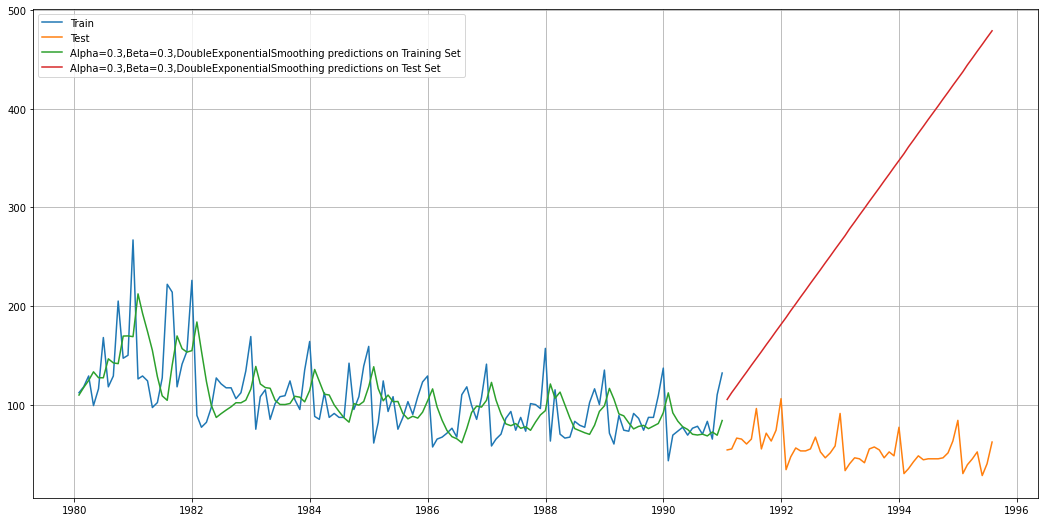

In [172]:
## Plotting on both the Training and Test data

plt.figure(figsize=(18,9))
plt.plot(DES_train['Rose'], label='Train')
plt.plot(DES_test['Rose'], label='Test')

plt.plot(DES_train['predict', 0.3, 0.3], label='Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing predictions on Training Set')
plt.plot(DES_test['predict', 0.3, 0.3], label='Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid();

In [173]:
resultsDf2 = pd.DataFrame({'Test RMSE': [resultsDf_1['Test RMSE'][0]],'Test MAPE':[resultsDf_1['Test MAPE'][0]]}
                           ,index=['Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing'])

In [174]:
resultsDf2

,Test RMSE,Test MAPE
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68


In [175]:
resultsDf_2 = pd.concat([resultsDf, resultsDf2])
resultsDf_2

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68


### Method 3: Triple Exponential Smoothing

In [176]:
TES_train = train.copy()
TES_test = test.copy()

In [177]:
model_TES = ExponentialSmoothing(TES_train['Rose'])

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


### Model Evaluation

In [178]:
## First we will define an empty dataframe to store our values from the loop

resultsDf3 = pd.DataFrame({'Alpha Values':[],'Beta Values':[],'Gamma Values':[],'Train RMSE':[],'Train MAPE':[]
                                ,'Test RMSE': [],'Test MAPE': []})
resultsDf3

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE


In [179]:
for i in np.arange(0.3,1.1,0.1):
    for j in np.arange(0.3,1.1,0.1):
        for k in np.arange(0.3,1.1,0.1):
            model_TES_alpha_i_j_k = model_TES.fit(smoothing_level=i,smoothing_slope=j,smoothing_seasonal=k,optimized=True,use_brute=True)
            TES_train['predict',i,j,k] = model_TES_alpha_i_j_k.fittedvalues
            TES_test['predict',i,j,k] = model_TES_alpha_i_j_k.forecast(steps=55)
        
            rmse_model3_train = metrics.mean_squared_error(TES_train['Rose'],TES_train['predict',i,j,k],squared=False)
            mape_model3_train = MAPE(TES_train['Rose'],TES_train['predict',i,j,k])
        
            rmse_model3_test = metrics.mean_squared_error(TES_test['Rose'],TES_test['predict',i,j,k],squared=False)
            mape_model3_test = MAPE(TES_test['Rose'],TES_test['predict',i,j,k])
        
            resultsDf3 = resultsDf3.append({'Alpha Values':i,'Beta Values':j,'Gamma Values':k,'Train RMSE':rmse_model3_train
                                      ,'Train MAPE': mape_model3_train,'Test RMSE':rmse_model3_test
                                      ,'Test MAPE':mape_model3_test}, ignore_index=True)

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greater_equal
  loc = initial_p >= ub
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters.py:731: RuntimeWarning: invalid value encountered in greate

In [180]:
resultsDf3

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,0.3,32.448833,22.31,47.525251,83.77
1,0.3,0.3,0.4,32.448833,22.31,47.525251,83.77
2,0.3,0.3,0.5,32.448833,22.31,47.525251,83.77
3,0.3,0.3,0.6,32.448833,22.31,47.525251,83.77
4,0.3,0.3,0.7,32.448833,22.31,47.525251,83.77
...,...,...,...,...,...,...,...
507,1.0,1.0,0.6,38.783783,24.75,79.738550,145.19
508,1.0,1.0,0.7,38.783783,24.75,79.738550,145.19
509,1.0,1.0,0.8,38.783783,24.75,79.738550,145.19
510,1.0,1.0,0.9,38.783783,24.75,79.738550,145.19


In [181]:
resultsDf3.sort_values(by=['Test RMSE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,0.3,32.448833,22.31,47.525251,83.77
34,0.3,0.7,0.5,32.448833,22.31,47.525251,83.77
35,0.3,0.7,0.6,32.448833,22.31,47.525251,83.77
36,0.3,0.7,0.7,32.448833,22.31,47.525251,83.77
37,0.3,0.7,0.8,32.448833,22.31,47.525251,83.77


In [182]:
resultsDf3.sort_values(by=['Test MAPE']).head()

,Alpha Values,Beta Values,Gamma Values,Train RMSE,Train MAPE,Test RMSE,Test MAPE
0,0.3,0.3,0.3,32.448833,22.31,47.525251,83.77
34,0.3,0.7,0.5,32.448833,22.31,47.525251,83.77
35,0.3,0.7,0.6,32.448833,22.31,47.525251,83.77
36,0.3,0.7,0.7,32.448833,22.31,47.525251,83.77
37,0.3,0.7,0.8,32.448833,22.31,47.525251,83.77


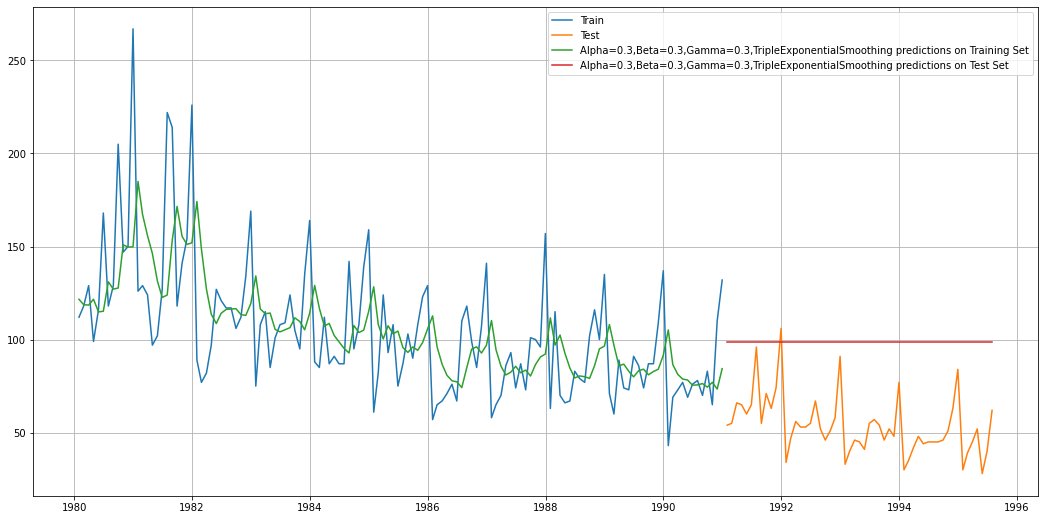

In [183]:
## Plotting on both the Training and Test data using brute force alpha, beta and gamma determination

plt.figure(figsize=(18,9))
plt.plot(TES_train['Rose'], label='Train')
plt.plot(TES_test['Rose'], label='Test')

plt.plot(TES_train['predict', 0.3, 0.3, 0.3], label='Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing predictions on Training Set')
plt.plot(TES_test['predict', 0.3, 0.3, 0.3], label='Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing predictions on Test Set')

plt.legend(loc='best')
plt.grid();

In [184]:
results3 = pd.DataFrame({'Test RMSE': [resultsDf3['Test RMSE'][0]],'Test MAPE':[resultsDf3['Test MAPE'][0]]}
                           ,index=['Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing'])

resultsDf_3 = pd.concat([resultsDf_2, results3])
resultsDf_3

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77


### Method 4: Linear Regression

In [185]:
train_time = [i+1 for i in range(len(train))]
test_time = [i+133 for i in range(len(test))]
print('Training Time instance','\n',train_time)
print('Test Time instance','\n',test_time)

Training Time instance 
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]
Test Time instance 
 [133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187]


In [186]:
LinearRegression_train = train.copy()
LinearRegression_test = test.copy()

In [187]:
LinearRegression_train['time'] = train_time
LinearRegression_test['time'] = test_time

print('First few rows of Training Data','\n',LinearRegression_train.head(),'\n')
print('Last few rows of Training Data','\n',LinearRegression_train.tail(),'\n')
print('First few rows of Test Data','\n',LinearRegression_test.head(),'\n')
print('Last few rows of Test Data','\n',LinearRegression_test.tail(),'\n')

First few rows of Training Data 
              Rose  time
Time_Stamp             
1980-01-31  112.0     1
1980-02-29  118.0     2
1980-03-31  129.0     3
1980-04-30   99.0     4
1980-05-31  116.0     5 

Last few rows of Training Data 
              Rose  time
Time_Stamp             
1990-08-31   70.0   128
1990-09-30   83.0   129
1990-10-31   65.0   130
1990-11-30  110.0   131
1990-12-31  132.0   132 

First few rows of Test Data 
             Rose  time
Time_Stamp            
1991-01-31  54.0   133
1991-02-28  55.0   134
1991-03-31  66.0   135
1991-04-30  65.0   136
1991-05-31  60.0   137 

Last few rows of Test Data 
             Rose  time
Time_Stamp            
1995-03-31  45.0   183
1995-04-30  52.0   184
1995-05-31  28.0   185
1995-06-30  40.0   186
1995-07-31  62.0   187 



In [188]:
lr = LinearRegression()

In [189]:
lr.fit(LinearRegression_train[['time']],LinearRegression_train['Rose'].values)

LinearRegression()

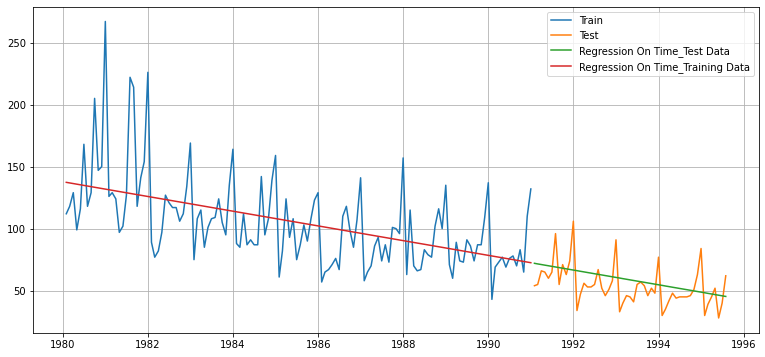

In [190]:
train_predictions_model4 = lr.predict(LinearRegression_train[['time']])
LinearRegression_train['RegOnTime'] = train_predictions_model4

test_predictions_model4 = lr.predict(LinearRegression_test[['time']])
LinearRegression_test['RegOnTime'] = test_predictions_model4

plt.figure(figsize=(13,6))
plt.plot(train['Rose'], label='Train')
plt.plot(test['Rose'], label='Test')
plt.plot(LinearRegression_test['RegOnTime'], label='Regression On Time_Test Data')
plt.plot(LinearRegression_train['RegOnTime'], label='Regression On Time_Training Data')
plt.legend(loc='best')
plt.grid();

### Model Evaluation

In [191]:
rmse_model4_train = metrics.mean_squared_error(train['Rose'],train_predictions_model4,squared=False)
mape_model4_train = MAPE(train['Rose'],train_predictions_model4)
print("For RegressionOnTime forecast on the Training Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model4_train, mape_model4_train))

For RegressionOnTime forecast on the Training Data,  RMSE is 30.718 MAPE is 21.22


In [192]:
rmse_model4_test = metrics.mean_squared_error(test['Rose'],test_predictions_model4,squared=False)
mape_model4_test = MAPE(test['Rose'],test_predictions_model4)
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model4_test, mape_model4_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 15.276 MAPE is 22.86


In [193]:
resultsDf4 = pd.DataFrame({'Test RMSE': [rmse_model4_test],'Test MAPE': [mape_model4_test]},index=['RegressionOnTime'])
resultsDf4

,Test RMSE,Test MAPE
RegressionOnTime,15.275732,22.86


In [194]:
resultsDf_4 = pd.concat([resultsDf_3,resultsDf4])
resultsDf_4

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86


### Method 5: Naive Approach

In [195]:
NaiveModel_train = train.copy()
NaiveModel_test = test.copy()

In [196]:
## Let us get the last value (or the most recent value) of the training set.

NaiveModel_train['naive'] = np.asarray(train['Rose'])[len(np.asarray(train['Rose']))-1]
NaiveModel_train['naive'].head()

Time_Stamp
1980-01-31    132.0
1980-02-29    132.0
1980-03-31    132.0
1980-04-30    132.0
1980-05-31    132.0
Name: naive, dtype: float64

In [197]:
NaiveModel_test['naive'] = np.asarray(test['Rose'])[len(np.asarray(test['Rose']))-1]
NaiveModel_test['naive'].head()

Time_Stamp
1991-01-31    62.0
1991-02-28    62.0
1991-03-31    62.0
1991-04-30    62.0
1991-05-31    62.0
Name: naive, dtype: float64

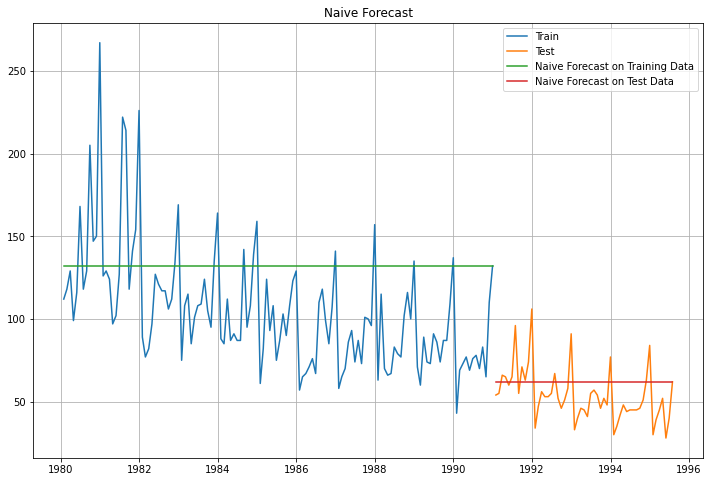

In [198]:
plt.figure(figsize=(12,8))
plt.plot(NaiveModel_train['Rose'], label='Train')
plt.plot(test['Rose'], label='Test')
plt.plot(NaiveModel_train['naive'], label='Naive Forecast on Training Data')
plt.plot(NaiveModel_test['naive'], label='Naive Forecast on Test Data')
plt.legend(loc='best')
plt.title("Naive Forecast")
plt.grid();

### Model Evaluation

In [199]:
## Training Data - RMSE and MAPE

rmse_model5_train = metrics.mean_squared_error(train['Rose'],NaiveModel_train['naive'],squared=False)
mape_model5_train = MAPE(train['Rose'],NaiveModel_train['naive'])
print("For Naive Model forecast on the Training Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model5_train, mape_model5_train))

For Naive Model forecast on the Training Data,  RMSE is 45.064 MAPE is 36.38


In [200]:
## Test Data - RMSE and MAPE

rmse_model5_test = metrics.mean_squared_error(test['Rose'],NaiveModel_test['naive'],squared=False)
mape_model5_test = MAPE(test['Rose'],NaiveModel_test['naive'])
print("For RegressionOnTime forecast on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model5_test, mape_model5_test))

For RegressionOnTime forecast on the Test Data,  RMSE is 17.757 MAPE is 27.46


In [201]:
results5 = pd.DataFrame({'Test RMSE': [rmse_model5_test],'Test MAPE': [mape_model5_test]},index=['NaiveModel'])
results5

,Test RMSE,Test MAPE
NaiveModel,17.757457,27.46


In [202]:
resultsDf_5 = pd.concat([resultsDf_4, results5])
resultsDf_5

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86
NaiveModel,17.757457,27.46


### Method 6: Simple Average Concept

In [203]:
SimpleAverage_train = train.copy()
SimpleAverage_test = test.copy()

In [204]:
## Let us get the last value (or the most recent value) of the training set.

SimpleAverage_train['mean_forecast'] = train['Rose'].mean()
SimpleAverage_train.head()

,Rose,mean_forecast
Time_Stamp,,
1980-01-31,112.0,104.939394
1980-02-29,118.0,104.939394
1980-03-31,129.0,104.939394
1980-04-30,99.0,104.939394
1980-05-31,116.0,104.939394


In [205]:
SimpleAverage_test['mean_forecast'] = test['Rose'].mean()
SimpleAverage_test.head()

,Rose,mean_forecast
Time_Stamp,,
1991-01-31,54.0,53.836364
1991-02-28,55.0,53.836364
1991-03-31,66.0,53.836364
1991-04-30,65.0,53.836364
1991-05-31,60.0,53.836364


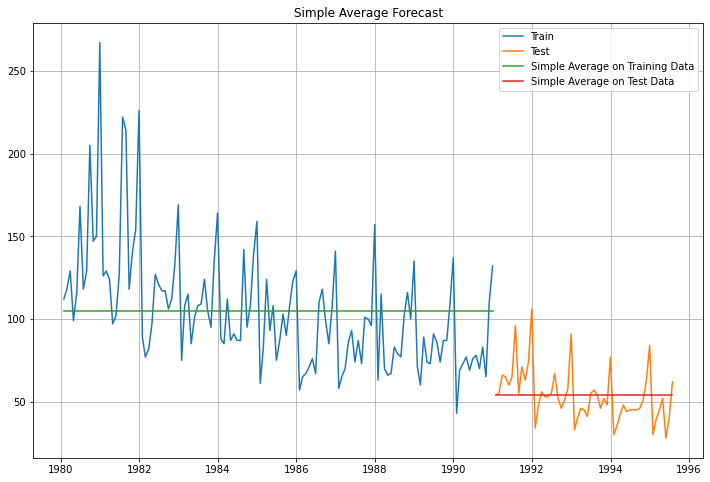

In [206]:
plt.figure(figsize=(12,8))
plt.plot(SimpleAverage_train['Rose'], label='Train')
plt.plot(SimpleAverage_test['Rose'], label='Test')
plt.plot(SimpleAverage_train['mean_forecast'], label='Simple Average on Training Data')
plt.plot(SimpleAverage_test['mean_forecast'], label='Simple Average on Test Data')
plt.legend(loc='best')
plt.title("Simple Average Forecast")
plt.grid();

### Model Evaluation

In [207]:
## Training Data - RMSE and MAPE

rmse_model6_train = metrics.mean_squared_error(train['Rose'],SimpleAverage_train['mean_forecast'],squared=False)
mape_model6_train = MAPE(train['Rose'],SimpleAverage_train['mean_forecast'])
print("For Simple Average Model forecast on the Training Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model6_train, mape_model6_train))

For Simple Average Model forecast on the Training Data,  RMSE is 36.034 MAPE is 25.39


In [208]:
## Test Data - RMSE and MAPE

rmse_model6_test = metrics.mean_squared_error(test['Rose'],SimpleAverage_test['mean_forecast'],squared=False)
mape_model6_test = MAPE(test['Rose'],SimpleAverage_test['mean_forecast'])
print("For Simple Average forecast on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model6_test, mape_model6_test))

For Simple Average forecast on the Test Data,  RMSE is 15.770 MAPE is 21.41


In [209]:
results6 = pd.DataFrame({'Test RMSE': [rmse_model6_test],'Test MAPE': [mape_model6_test]}
                           ,index=['SimpleAverageModel'])

results6

,Test RMSE,Test MAPE
SimpleAverageModel,15.769664,21.41


In [210]:
resultsDf_6 = pd.concat([resultsDf_5, results6])
resultsDf_6

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86
NaiveModel,17.757457,27.46
SimpleAverageModel,15.769664,21.41


### Method 7: Moving Average Concept

In [211]:
MovingAverage = df2.copy()
MovingAverage.head()

,Rose
Time_Stamp,
1980-01-31,112.0
1980-02-29,118.0
1980-03-31,129.0
1980-04-30,99.0
1980-05-31,116.0


In [212]:
MovingAverage['Trailing_2'] = MovingAverage['Rose'].rolling(2).mean()
MovingAverage['Trailing_4'] = MovingAverage['Rose'].rolling(4).mean()
MovingAverage['Trailing_6'] = MovingAverage['Rose'].rolling(6).mean()
MovingAverage['Trailing_9'] = MovingAverage['Rose'].rolling(9).mean()

MovingAverage.head()

,Rose,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1980-01-31,112.0,NaN,NaN,NaN,NaN
1980-02-29,118.0,115.0,NaN,NaN,NaN
1980-03-31,129.0,123.5,NaN,NaN,NaN
1980-04-30,99.0,114.0,114.5,NaN,NaN
1980-05-31,116.0,107.5,115.5,NaN,NaN


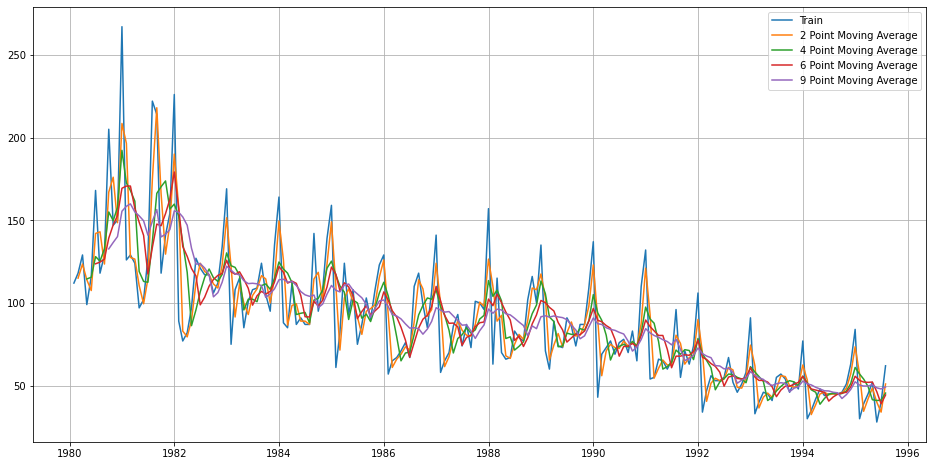

In [213]:
## Plotting on the whole data

plt.figure(figsize=(16,8))
plt.plot(MovingAverage['Rose'], label='Train')
plt.plot(MovingAverage['Trailing_2'], label='2 Point Moving Average')
plt.plot(MovingAverage['Trailing_4'], label='4 Point Moving Average')
plt.plot(MovingAverage['Trailing_6'],label = '6 Point Moving Average')
plt.plot(MovingAverage['Trailing_9'],label = '9 Point Moving Average')

plt.legend(loc = 'best')
plt.grid();

In [214]:
#Creating train and test set 
trailing_MovingAverage_train=MovingAverage[0:int(len(MovingAverage)*0.7)] 
trailing_MovingAverage_test=MovingAverage[int(len(MovingAverage)*0.7):]

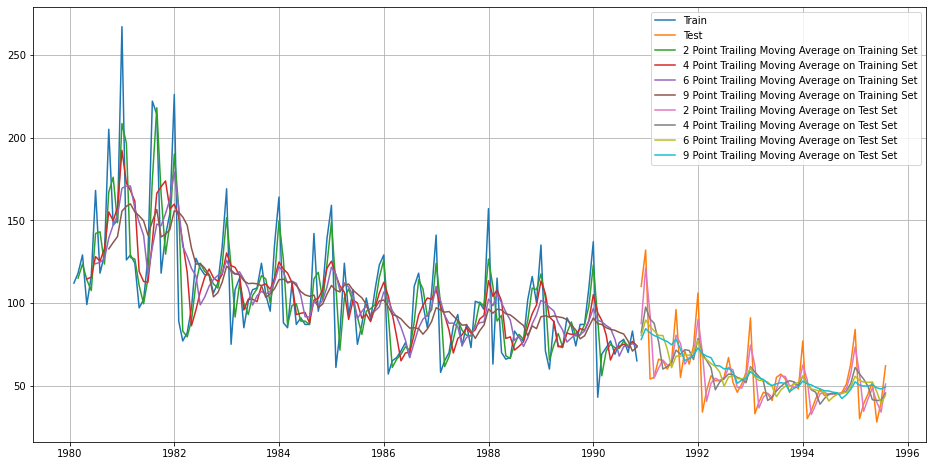

In [215]:
## Plotting on both the Training and Test data

plt.figure(figsize=(16,8))
plt.plot(trailing_MovingAverage_train['Rose'], label='Train')
plt.plot(trailing_MovingAverage_test['Rose'], label='Test')

plt.plot(trailing_MovingAverage_train['Trailing_2'], label='2 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_4'], label='4 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_6'],label = '6 Point Trailing Moving Average on Training Set')
plt.plot(trailing_MovingAverage_train['Trailing_9'],label = '9 Point Trailing Moving Average on Training Set')

plt.plot(trailing_MovingAverage_test['Trailing_2'], label='2 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_4'], label='4 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_6'],label = '6 Point Trailing Moving Average on Test Set')
plt.plot(trailing_MovingAverage_test['Trailing_9'],label = '9 Point Trailing Moving Average on Test Set')
plt.legend(loc = 'best')
plt.grid();

In [216]:
test.head()

,Rose
Time_Stamp,
1991-01-31,54.0
1991-02-28,55.0
1991-03-31,66.0
1991-04-30,65.0
1991-05-31,60.0


In [217]:
trailing_MovingAverage_test.head()

,Rose,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1990-11-30,110.0,87.5,82.00,80.333333,77.888889
1990-12-31,132.0,121.0,97.50,89.666667,84.444444
1991-01-31,54.0,93.0,90.25,85.666667,81.888889
1991-02-28,55.0,54.5,87.75,83.166667,80.333333
1991-03-31,66.0,60.5,76.75,80.333333,79.222222


In [218]:
trailing_MovingAverage_test[2:]

,Rose,Trailing_2,Trailing_4,Trailing_6,Trailing_9
Time_Stamp,,,,,
1991-01-31,54.0,93.0,90.25,85.666667,81.888889
1991-02-28,55.0,54.5,87.75,83.166667,80.333333
1991-03-31,66.0,60.5,76.75,80.333333,79.222222
1991-04-30,65.0,65.5,60.00,80.333333,77.777778
1991-05-31,60.0,62.5,61.50,72.000000,76.666667
1991-06-30,65.0,62.5,64.00,60.833333,74.666667
1991-07-31,96.0,80.5,71.50,67.833333,78.111111
1991-08-31,55.0,75.5,69.00,67.833333,72.000000
1991-09-30,71.0,63.0,71.75,68.666667,65.222222


### Model Evaluation

In [219]:
## Test Data - RMSE and MAPE --> 2 point Trailing MA

rmse_model7_test_2 = metrics.mean_squared_error(test['Rose'],trailing_MovingAverage_test['Trailing_2'][2:],squared=False)
mape_model7_test_2 = MAPE(test['Rose'],trailing_MovingAverage_test['Trailing_2'][2:])
print("For 2 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_2, mape_model7_test_2))

## Test Data - RMSE and MAPE --> 4 point Trailing MA

rmse_model7_test_4 = metrics.mean_squared_error(test['Rose'],trailing_MovingAverage_test['Trailing_4'][2:],squared=False)
mape_model7_test_4 = MAPE(test['Rose'],trailing_MovingAverage_test['Trailing_4'][2:])
print("For 4 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_4, mape_model7_test_4))

## Test Data - RMSE and MAPE --> 6 point Trailing MA

rmse_model7_test_6 = metrics.mean_squared_error(test['Rose'],trailing_MovingAverage_test['Trailing_6'][2:],squared=False)
mape_model7_test_6 = MAPE(test['Rose'],trailing_MovingAverage_test['Trailing_6'][2:])
print("For 6 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_6, mape_model7_test_6))

## Test Data - RMSE and MAPE --> 9 point Trailing MA

rmse_model7_test_9 = metrics.mean_squared_error(test['Rose'],trailing_MovingAverage_test['Trailing_9'][2:],squared=False)
mape_model7_test_9 = MAPE(test['Rose'],trailing_MovingAverage_test['Trailing_9'][2:])
print("For 9 point Moving Average Model forecast on the Testing Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model7_test_9, mape_model7_test_9))

For 2 point Moving Average Model forecast on the Testing Data,  RMSE is 11.529 MAPE is 13.54
For 4 point Moving Average Model forecast on the Testing Data,  RMSE is 14.455 MAPE is 19.51
For 6 point Moving Average Model forecast on the Testing Data,  RMSE is 14.572 MAPE is 20.82
For 9 point Moving Average Model forecast on the Testing Data,  RMSE is 14.731 MAPE is 21.05


In [220]:
results7 = pd.DataFrame({'Test RMSE': [rmse_model7_test_2,rmse_model7_test_4
                                          ,rmse_model7_test_6,rmse_model7_test_9]
                            ,'Test MAPE': [mape_model7_test_2,mape_model7_test_4,mape_model7_test_6
                                           ,mape_model7_test_9]}
                           ,index=['2pointTrailingMovingAverage','4pointTrailingMovingAverage'
                                   ,'6pointTrailingMovingAverage','9pointTrailingMovingAverage'])

resultsDf_7 = pd.concat([resultsDf_6, results7])
resultsDf_7

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86
NaiveModel,17.757457,27.46
SimpleAverageModel,15.769664,21.41
2pointTrailingMovingAverage,11.529409,13.54
4pointTrailingMovingAverage,14.455221,19.51
6pointTrailingMovingAverage,14.572009,20.82


## 5. Check for the stationarity of the data on which the model is being built on using appropriate statistical tests and also mention the hypothesis for the statistical test. If the data is found to be non-stationary, take appropriate steps to make it stationary. Check the new data for stationarity and comment.
## Note: Stationarity should be checked at alpha = 0.05.

## Ans:

In [221]:
## Test for stationarity of the series - Dicky Fuller test

from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=7).mean()
    rolstd = timeseries.rolling(window=7).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print (dfoutput,'\n')

### The Null Hypothesis: The data on which the model is being built is not stationary.
### The Alternate hypothesis: The data on which the model is being built is stationary.
### For this check, we will consider the p_value, and considering alpha = 0.05:
### if p_value is low - null hypothesis is rejected.
### if p_value is high - alternate hypothesis is rejected.

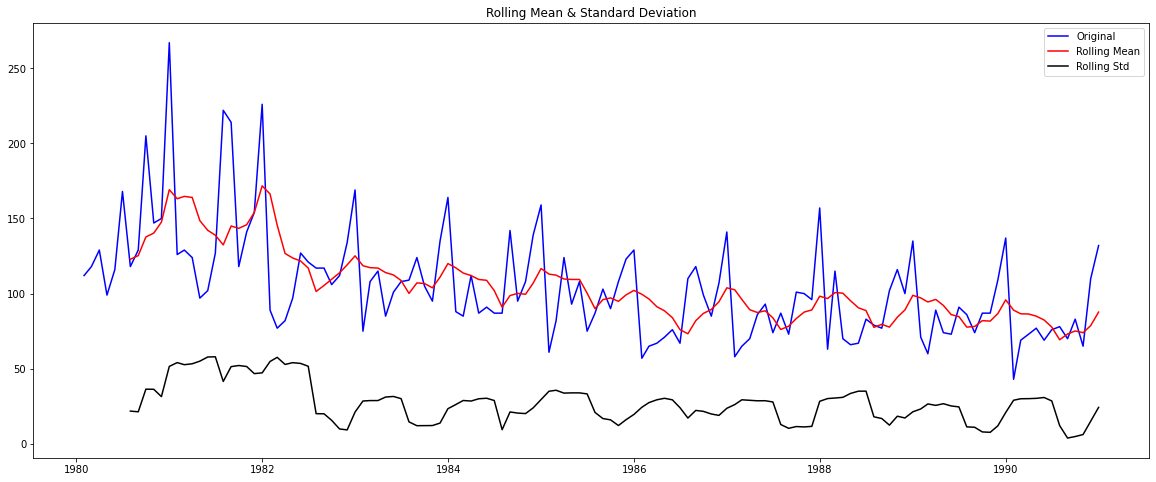

Results of Dickey-Fuller Test:
Test Statistic                  -2.164250
p-value                          0.219476
#Lags Used                      13.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64 



In [222]:
test_stationarity(train['Rose'])

### Loking at above p_value, we see that the time series is not stationary at α = 0.05

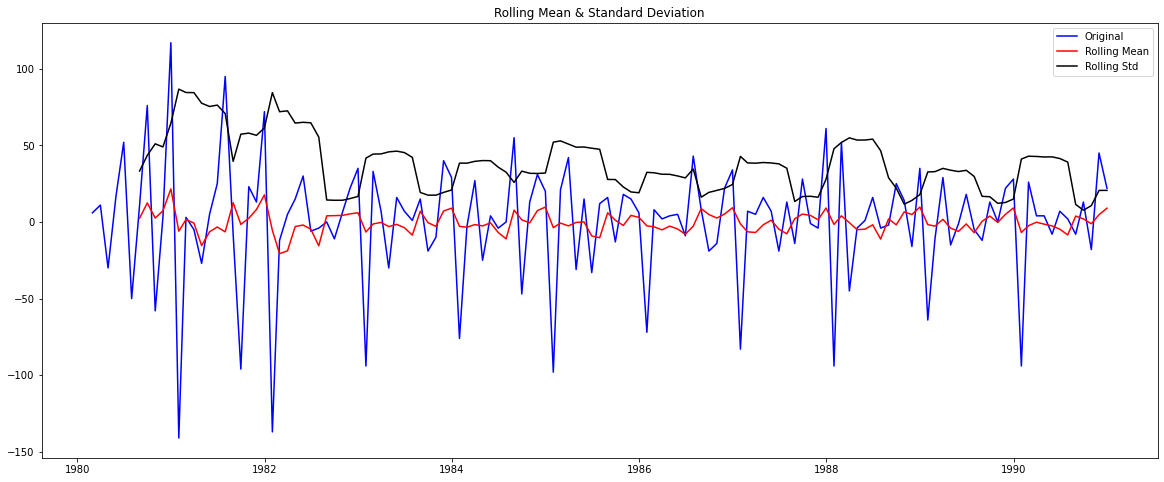

Results of Dickey-Fuller Test:
Test Statistic                -6.592372e+00
p-value                        7.061944e-09
#Lags Used                     1.200000e+01
Number of Observations Used    1.180000e+02
Critical Value (1%)           -3.487022e+00
Critical Value (5%)           -2.886363e+00
Critical Value (10%)          -2.580009e+00
dtype: float64 



In [223]:
test_stationarity(train['Rose'].diff().dropna())

### Looking at the above p_value, we see that after taking a difference of order 1 the time series have become stationary at α = 0.05
### Note: The series is non-stationary, we will stationarize the Time Series by taking a difference of the Time Series. Then we will use this particular differenced series to train the ARIMA models. We do not need to worry about stationarity for the Test Data because we are not building any models on the Test Data, we are evaluating our models over there.

## 6. Build an automated version of the ARIMA/SARIMA model in which the parameters are selected using the lowest Akaike Information Criteria (AIC) on the training data and evaluate this model on the test data using RMSE.

## Ans:

In [224]:
## The following loop helps us in getting a combination of different parameters of p and q in the range of 0 and 2
## We have kept the value of d as 1 as we need to take a difference of the series to make it stationary.

import itertools
p = q = range(0, 3)
d= range(1,2)
pdq = list(itertools.product(p, d, q))
print('Some parameter combinations for the Model...')
for i in range(1,len(pdq)):
    print('Model: {}'.format(pdq[i]))

Some parameter combinations for the Model...
Model: (0, 1, 1)
Model: (0, 1, 2)
Model: (1, 1, 0)
Model: (1, 1, 1)
Model: (1, 1, 2)
Model: (2, 1, 0)
Model: (2, 1, 1)
Model: (2, 1, 2)


In [225]:
# Creating an empty Dataframe with column names only
ARIMA_AIC = pd.DataFrame(columns=['param', 'AIC'])
ARIMA_AIC

,param,AIC


In [226]:
from statsmodels.tsa.arima_model import ARIMA

for param in pdq:
    ARIMA_model = ARIMA(train['Rose'].values,order=param).fit()
    print('ARIMA{} - AIC:{}'.format(param,ARIMA_model.aic))
    ARIMA_AIC = ARIMA_AIC.append({'param':param, 'AIC': ARIMA_model.aic}, ignore_index=True)

ARIMA(0, 1, 0) - AIC:1335.1526583086775
ARIMA(0, 1, 1) - AIC:1280.7261830464045
ARIMA(0, 1, 2) - AIC:1276.8353720852406
ARIMA(1, 1, 0) - AIC:1319.348310580188
ARIMA(1, 1, 1) - AIC:1277.775747885047
ARIMA(1, 1, 2) - AIC:1277.3592217495348
ARIMA(2, 1, 0) - AIC:1300.6092611747547
ARIMA(2, 1, 1) - AIC:1279.045689409309
ARIMA(2, 1, 2) - AIC:1279.2986939365824


In [227]:
## Sort the above AIC values in the ascending order to get the parameters for the minimum AIC value

ARIMA_AIC.sort_values(by='AIC',ascending=True)

,param,AIC
2,"(0, 1, 2)",1276.835372
5,"(1, 1, 2)",1277.359222
4,"(1, 1, 1)",1277.775748
7,"(2, 1, 1)",1279.045689
8,"(2, 1, 2)",1279.298694
1,"(0, 1, 1)",1280.726183
6,"(2, 1, 0)",1300.609261
3,"(1, 1, 0)",1319.348311
0,"(0, 1, 0)",1335.152658


In [228]:
auto_ARIMA = ARIMA(train['Rose'], order=(0,1,2),freq='M')

results_auto_ARIMA = auto_ARIMA.fit()

print(results_auto_ARIMA.summary())

                             ARIMA Model Results                              
Dep. Variable:                 D.Rose   No. Observations:                  131
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -634.418
Method:                       css-mle   S.D. of innovations             30.167
Date:                Thu, 26 Jun 2025   AIC                           1276.835
Time:                        13:50:38   BIC                           1288.336
Sample:                    02-29-1980   HQIC                          1281.509
                         - 12-31-1990                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4885      0.085     -5.742      0.000      -0.655      -0.322
ma.L1.D.Rose    -0.7601      0.101     -7.499      0.000      -0.959      -0.561
ma.L2.D.Rose    -0.2398      0.095     -2.51

### Predict on the Test Set using this model and evaluate the model

In [229]:
predicted_auto_ARIMA = results_auto_ARIMA.forecast(steps=len(test))

In [230]:
from sklearn.metrics import  mean_squared_error
rmse = mean_squared_error(test['Rose'],predicted_auto_ARIMA[0],squared=False)
print(rmse)

15.624630924762409


In [231]:
rmse_model8_test = metrics.mean_squared_error(test['Rose'],predicted_auto_ARIMA[0],squared=False)
mape_model8_test = MAPE(test['Rose'],predicted_auto_ARIMA[0])
print("For Automated Version of ARIMA/SARIMA using Lowest AIC on the training data and evaluating on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model8_test, mape_model8_test))

For Automated Version of ARIMA/SARIMA using Lowest AIC on the training data and evaluating on the Test Data,  RMSE is 15.625 MAPE is 23.31


In [232]:
results8 = pd.DataFrame({'Test RMSE': [rmse_model8_test],'Test MAPE': [mape_model8_test]}
                           ,index=[' Auto ARIMA (0,1,2)'])

results8

,Test RMSE,Test MAPE
"Auto ARIMA (0,1,2)",15.624631,23.31


In [233]:
resultsDf_8 = pd.concat([resultsDf_7, results8])
resultsDf_8

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86
NaiveModel,17.757457,27.46
SimpleAverageModel,15.769664,21.41
2pointTrailingMovingAverage,11.529409,13.54
4pointTrailingMovingAverage,14.455221,19.51
6pointTrailingMovingAverage,14.572009,20.82


## 7. Build ARIMA/SARIMA models based on the cut-off points of ACF and PACF on the training data and evaluate this model on the test data using RMSE.

## Ans:

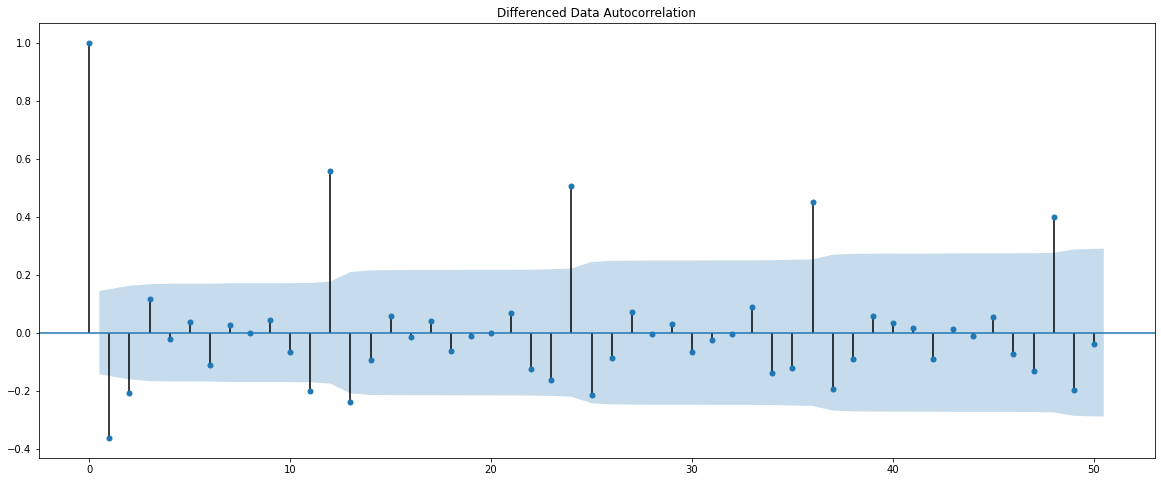

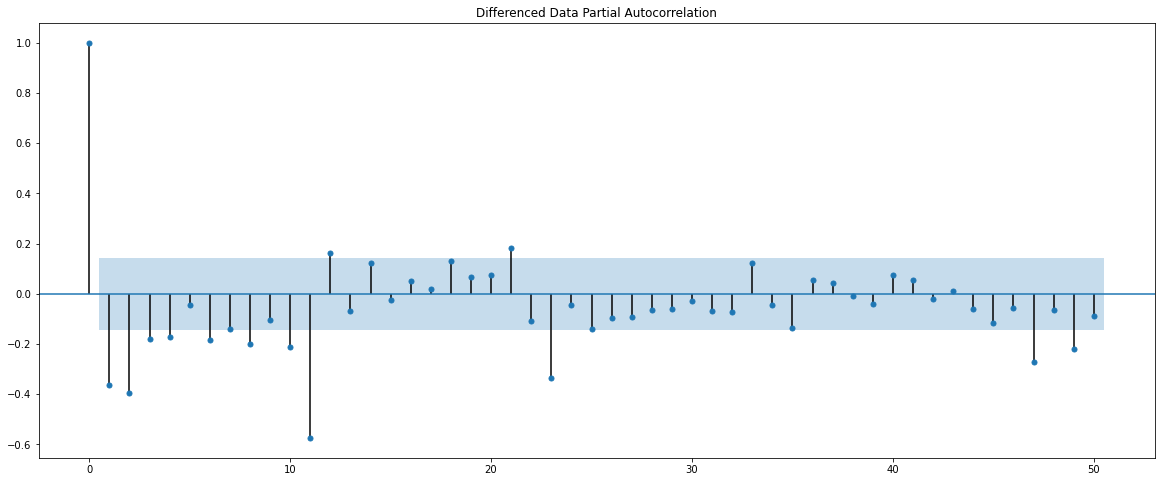

In [234]:
plot_acf(df2['Rose'].diff().dropna(),lags=50,title='Differenced Data Autocorrelation')
plot_pacf(df2['Rose'].diff().dropna(),lags=50,title='Differenced Data Partial Autocorrelation')
plt.show()

### The Auto-Regressive parameter in an ARIMA model is 'p' which comes from the lag at which the PACF plot cuts-off to 0 which is 4.
### The Moving-Average parameter in an ARIMA model is 'q' which comes from the lag at which the ACF plot cuts-off to 0 which is 2.

In [235]:
manual_ARIMA = ARIMA(train['Rose'], order=(4,1,2),freq='M')

results_manual_ARIMA = manual_ARIMA.fit()

print(results_manual_ARIMA.summary())

                             ARIMA Model Results                              
Dep. Variable:                 D.Rose   No. Observations:                  131
Model:                 ARIMA(4, 1, 2)   Log Likelihood                -633.876
Method:                       css-mle   S.D. of innovations             29.793
Date:                Thu, 26 Jun 2025   AIC                           1283.753
Time:                        13:50:40   BIC                           1306.754
Sample:                    02-29-1980   HQIC                          1293.099
                         - 12-31-1990                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.1905      0.576     -0.331      0.741      -1.319       0.938
ar.L1.D.Rose     1.1685      0.087     13.391      0.000       0.997       1.340
ar.L2.D.Rose    -0.3562      0.132     -2.69

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\base\model.py:547: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warn('Inverting hessian failed, no bse or cov_params '
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\arima_model.py:1490: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(-inv(hess)))
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\scipy\stats\_distn_infrastructure.py:1932: RuntimeWarning: invalid value encountered in less_equal
  cond2 = cond0 & (x <= _a)


### Predict on the Test Set using this model and evaluate the model.

In [236]:
predicted_manual_ARIMA = results_manual_ARIMA.forecast(steps=len(test))

In [237]:
rmse_model9_test = metrics.mean_squared_error(test['Rose'],predicted_manual_ARIMA[0],squared=False)
mape_model9_test = MAPE(test['Rose'],predicted_manual_ARIMA[0])
print("For Manual Version of ARIMA/SARIMA using ACF/PACF and evaluating on the Test Data,  RMSE is %3.3f MAPE is %3.2f" %(rmse_model9_test, mape_model9_test))

For Manual Version of ARIMA/SARIMA using ACF/PACF and evaluating on the Test Data,  RMSE is 33.969 MAPE is 58.47


In [238]:
results9 = pd.DataFrame({'Test RMSE': [rmse_model9_test],'Test MAPE': [mape_model9_test]}
                           ,index=[' Manual ARIMA (4,1,2)'])

results9

,Test RMSE,Test MAPE
"Manual ARIMA (4,1,2)",33.969016,58.47


In [239]:
resultsDf_9 = pd.concat([resultsDf_8, results9])
resultsDf_9

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86
NaiveModel,17.757457,27.46
SimpleAverageModel,15.769664,21.41
2pointTrailingMovingAverage,11.529409,13.54
4pointTrailingMovingAverage,14.455221,19.51
6pointTrailingMovingAverage,14.572009,20.82


## 8. Build a table with all the models built along with their corresponding parameters and the respective RMSE values on the test data.

## Ans:

In [240]:
resultsDf_9

,Test RMSE,Test MAPE
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77
"Alpha=0.4,SimpleExponentialSmoothing",53.787686,95.57
"Alpha=0.3,Beta=0.3,DoubleExponentialSmoothing",265.591922,442.68
"Alpha=0.3,Beta=0.3,Gamma=0.3,TripleExponentialSmoothing",47.525251,83.77
RegressionOnTime,15.275732,22.86
NaiveModel,17.757457,27.46
SimpleAverageModel,15.769664,21.41
2pointTrailingMovingAverage,11.529409,13.54
4pointTrailingMovingAverage,14.455221,19.51
6pointTrailingMovingAverage,14.572009,20.82


### The above table represents all the Models with their respective Test RMSE and Test MAPE values.

In [241]:
resultsDf_9.sort_values(by='Test RMSE',ascending=True)

,Test RMSE,Test MAPE
2pointTrailingMovingAverage,11.529409,13.54
4pointTrailingMovingAverage,14.455221,19.51
6pointTrailingMovingAverage,14.572009,20.82
9pointTrailingMovingAverage,14.731209,21.05
RegressionOnTime,15.275732,22.86
"Auto ARIMA (0,1,2)",15.624631,23.31
SimpleAverageModel,15.769664,21.41
NaiveModel,17.757457,27.46
"Manual ARIMA (4,1,2)",33.969016,58.47
"Alpha=0.3,SimpleExponentialSmoothing",47.525251,83.77


### The above table represents all the Models sorted by the lowest Test RMSE.

## 9. Based on the model-building exercise, build the most optimum model(s) on the complete data and predict 12 months into the future with appropriate confidence intervals/bands.

## Ans:

In [242]:
MovingAverage_model_future = df2.copy()

In [243]:
MovingAverage_model_future.tail()

,Rose
Time_Stamp,
1995-03-31,45.0
1995-04-30,52.0
1995-05-31,28.0
1995-06-30,40.0
1995-07-31,62.0


In [244]:
Month = pd.date_range(start='8/31/1995', end='7/31/1996', freq='M')

In [245]:
Month

DatetimeIndex(['1995-08-31', '1995-09-30', '1995-10-31', '1995-11-30',
               '1995-12-31', '1996-01-31', '1996-02-29', '1996-03-31',
               '1996-04-30', '1996-05-31', '1996-06-30', '1996-07-31'],
              dtype='datetime64[ns]', freq='M')

In [246]:
MovingAverage_model_future[-2:]

,Rose
Time_Stamp,
1995-06-30,40.0
1995-07-31,62.0


In [247]:
first_month_prediction = MovingAverage_model_future['Rose'][-2:].mean()
first_month_prediction

51.0

In [248]:
second_month_prediction = (first_month_prediction + MovingAverage_model_future['Rose'][-1:]).mean()
second_month_prediction

113.0

In [249]:
predictions = [first_month_prediction, second_month_prediction, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
predictions

[51.0, 113.0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [250]:
for i in np.arange(0,10,1):
    predictions[i+2] = (predictions[i] + predictions[i+1])/2

In [251]:
predictions

[51.0,
 113.0,
 82.0,
 97.5,
 89.75,
 93.625,
 91.6875,
 92.65625,
 92.171875,
 92.4140625,
 92.29296875,
 92.353515625]

In [252]:
Future_Predictions = pd.DataFrame({'Month':Month, 'Predictions_MA_2':predictions})

In [253]:
Future_Predictions

,Month,Predictions_MA_2
0,1995-08-31,51.000000
1,1995-09-30,113.000000
2,1995-10-31,82.000000
3,1995-11-30,97.500000
4,1995-12-31,89.750000
5,1996-01-31,93.625000
6,1996-02-29,91.687500
7,1996-03-31,92.656250
8,1996-04-30,92.171875
9,1996-05-31,92.414062


In [254]:
full_data_model = sm.tsa.statespace.SARIMAX(df2['Rose'],
                                order=(0,1,2),
                                seasonal_order=None,
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results_full_data_model = full_data_model.fit(maxiter=1000)
print(results_full_data_model.summary())

                               SARIMAX Results                                
Dep. Variable:                   Rose   No. Observations:                  187
Model:               SARIMAX(0, 1, 2)   Log Likelihood                -868.942
Date:                Thu, 26 Jun 2025   AIC                           1743.883
Time:                        13:50:42   BIC                           1753.512
Sample:                    01-31-1980   HQIC                          1747.786
                         - 07-31-1995                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7147      0.058    -12.381      0.000      -0.828      -0.602
ma.L2         -0.1708      0.057     -2.999      0.003      -0.282      -0.059
sigma2       775.3901     59.107     13.118      0.0

C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'
C:\Users\arigilasrinivas\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:159: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  warnings.warn('No frequency information was'


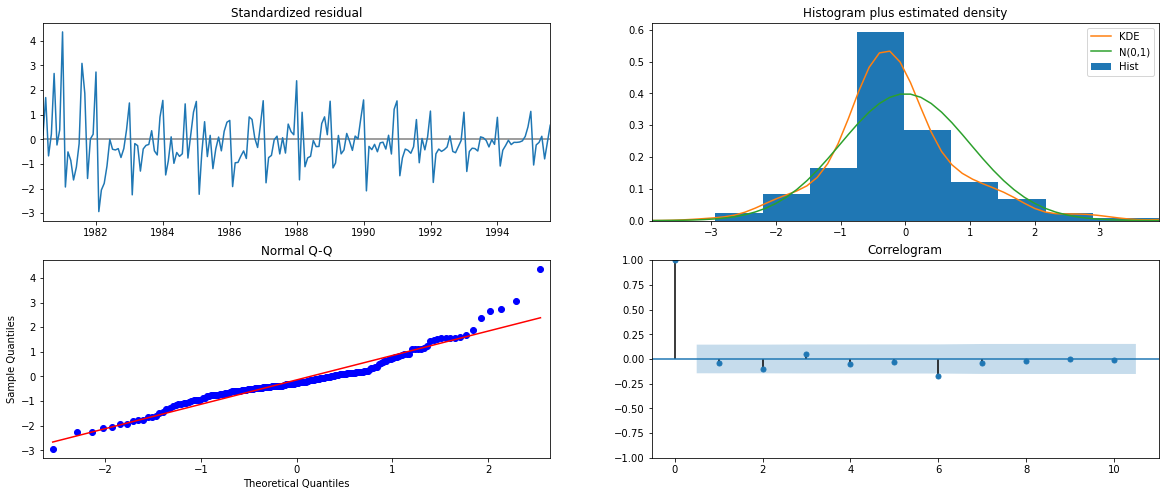

In [255]:
results_full_data_model.plot_diagnostics();

In [256]:
predicted_auto_ARIMA_full_data = results_full_data_model.get_forecast(steps=12)

In [257]:
predicted_auto_ARIMA_full_data.summary_frame(alpha=0.05).head()

Rose,mean,mean_se,mean_ci_lower,mean_ci_upper
1995-08-31,51.233588,27.845827,-3.343230,105.810407
1995-09-30,48.526609,28.956877,-8.227828,105.281045
1995-10-31,48.526609,29.131954,-8.570972,105.624189
1995-11-30,48.526609,29.305985,-8.912066,105.965283
1995-12-31,48.526609,29.478988,-9.251147,106.304364


In [258]:
pred_full_auto_ARIMA_date = predicted_auto_ARIMA_full_data.summary_frame(alpha=0.05).set_index(pd.date_range(start='1995-08-31',end='1996-07-31', freq='M'))

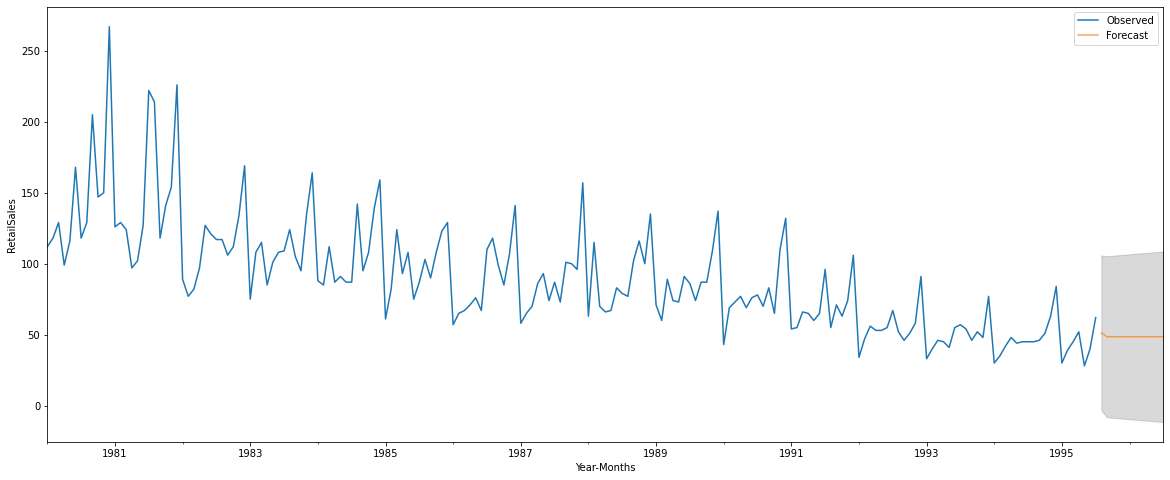

In [259]:
# plot the forecast along with the confidence band

axis = df2['Rose'].plot(label='Observed')
pred_full_auto_ARIMA_date['mean'].plot(ax=axis, label='Forecast', alpha=0.7)
axis.fill_between(pred_full_auto_ARIMA_date.index, pred_full_auto_ARIMA_date['mean_ci_lower'], 
                  pred_full_auto_ARIMA_date['mean_ci_upper'], color='k', alpha=.15)
axis.set_xlabel('Year-Months')
axis.set_ylabel('RetailSales')
plt.legend(loc='best')
plt.show()

In [260]:
pred_full_auto_ARIMA_date['mean']

1995-08-31    51.233588
1995-09-30    48.526609
1995-10-31    48.526609
1995-11-30    48.526609
1995-12-31    48.526609
1996-01-31    48.526609
1996-02-29    48.526609
1996-03-31    48.526609
1996-04-30    48.526609
1996-05-31    48.526609
1996-06-30    48.526609
1996-07-31    48.526609
Freq: M, Name: mean, dtype: float64

## 10. Comment on the model thus built and report your findings and suggest the measures that the company should be taking for future sales.

## Ans:

### From the above developed models, we can observe that the Moving Average Model performs better when compared to other models with respect to Test RMSE values being the least.
### We can also observe that, in terms of MAPE values as well, the Moving Average Model is performing better compared to other models.
### It can be noted that, the Logistic Regression has performed better compared to the ARIMA models with respect to both Test RMSE and Test MAPE.
### From the Time series plot we can observe that the Rose Wine sales have a decreasing trend as the year goes by.
### From the monthly plot, we can observe that the sales are high in the month of December. The reason for increase in sales could be due to Christmas season. 
### Considering that there is only a small increase in sales towards end of the year, it is necessary for the company to better market their products to beat the competitors and hit the highest peak possible during this season.
### The company is also required to know what other product has caused a decline in wine sales in order to improve the sales in the coming years.